# Imbalanced Classification: Zero to Hero

The topic where the standard advice is most confidently given and least well supported by
evidence — including, as it turns out, by the evidence in this notebook.

> **Prerequisites:** [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb)
> — especially §2 on leakage and §6–7 on metrics, thresholds and calibration, all of which this
> notebook leans on hard. [`logistic_regression_zero_to_hero.ipynb`](logistic_regression_zero_to_hero.ipynb)
> Part 3 is the threshold-selection material in full.

***

## Why this notebook exists

Ask how to handle imbalanced data and you will be told to resample — usually SMOTE. This
notebook measures whether that works, and the answer is uncomfortable:

- **Resampling almost never improved ranking.** §1.7 sweeps class separation, dimensionality
  and imbalance ratio: of **12** configurations, SMOTE reduced PR-AUC in **11** and improved it
  in one, by 0.003. §2.3 reproduces the pattern on real medical data.
- **Tuning the decision threshold beat every resampling method**, on the same model, for free.
  §1.6 measures F1 of **0.1341** from threshold tuning against **0.0581** for SMOTE.
- **Resampling destroys your probabilities.** §1.8: mean predicted probability goes from 0.0168
  (true rate 0.0160) to **0.39** — the model is now calibrated to a class balance that does not
  exist.
- **And the way it is usually applied silently fabricates results.** §3.1 runs SMOTE before
  cross-validation on **pure noise** and gets ROC-AUC **0.8323** and PR-AUC **0.7591**, where
  the truth is 0.50 and 0.043. This is the single largest leak measured anywhere in this series.

None of that means resampling is useless. It means it is a tool for shifting an operating
point, not for extracting signal — and there is usually a cheaper way to shift an operating
point.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports (adds `imbalanced-learn`) |
| **1. Theory from zero** | Why accuracy lies · **PR vs ROC** · the three levers · **SMOTE from scratch** · where interpolation goes wrong · **does any of it help?** · what it does to probabilities |
| **2. Worked example** | Mammography screening — 2.3% positives, and a real cost asymmetry |
| **3. The two things that matter** | **The resampling leak** · choosing a threshold from costs |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | Imbalance-specific errors and a checklist |

## The one-paragraph summary

When one class is rare, accuracy stops being informative (a 99% baseline needs no model) and
the default 0.5 threshold stops being sensible. Three levers can change what the model
predicts: **class weights**, **resampling** (random over/under-sampling, SMOTE) and **moving the
threshold**. They largely do the same thing — shift the operating point along a
precision/recall trade-off the model already encoded — and the third is free, reversible, and
does not corrupt your probabilities. The genuinely important disciplines are to **measure with
PR-AUC rather than accuracy or ROC-AUC**, to **choose the threshold from the actual cost of each
error**, and to **resample inside the cross-validation fold**, because doing it outside is the
most damaging leak in applied machine learning.

***
# Part 0 - Setup

This notebook adds one dependency beyond the series' usual five: **`imbalanced-learn`**, which
provides SMOTE and friends *and* — more importantly — an `imblearn.pipeline.Pipeline` that
applies resampling to training folds only. §3.1 shows why that distinction is not optional.

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
    ("imblearn", "imbalanced-learn"),          # new for this notebook
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

installing: imbalanced-learn
done


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
#
# Part 2 downloads the `mammography` benchmark (~1 MB) on first use and caches it.
# ---------------------------------------------------------------------------
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.datasets import fetch_datasets
from imblearn.over_sampling import (
    SMOTE, SMOTENC, ADASYN, BorderlineSMOTE, RandomOverSampler,
)
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline      # NOT sklearn's Pipeline

from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate, train_test_split,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, average_precision_score, roc_auc_score, f1_score,
    precision_score, recall_score, brier_score_loss, log_loss,
    confusion_matrix, precision_recall_curve, roc_curve, classification_report,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

SKF = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# An untreated model on imbalanced data often predicts NO positives, which makes
# precision undefined. sklearn's built-in "f1" and "precision" scorers warn in that
# case; these say explicitly that the answer is 0.
from sklearn.metrics import make_scorer
SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy",
}

import imblearn
print("ready | numpy", np.__version__, "| sklearn imported | imbalanced-learn",
      imblearn.__version__)

ready | numpy 2.5.2 | sklearn imported | imbalanced-learn 0.14.2


***
# Part 1 - Theory from zero

1. Why accuracy stops working
2. **The metrics that survive imbalance**
3. The three levers, and how similar they are
4. SMOTE from scratch
5. Where interpolation goes wrong
6. **Threshold moving does the same job, for free**
7. **Does resampling help at all?**
8. What resampling does to your probabilities

## 1.1 Why accuracy stops working

If 1.6% of your rows are positive, a model that predicts "negative" for everything scores 98.4%
accuracy. It has learned nothing, and it is right almost all the time.

That is not a subtle failure — but it generalises to a subtler one. Every metric that averages
over *all* rows is dominated by the majority class, and that includes some you might trust.

In [3]:
X, y = make_classification(n_samples=5000, n_features=20, n_informative=6, n_redundant=4,
                           weights=[0.99, 0.01], flip_y=0.01, class_sep=0.8,
                           random_state=RANDOM_STATE)
print(f"{len(y)} samples, {int(y.sum())} positives ({y.mean():.2%})")
print(f"imbalance ratio: {(1 - y.mean()) / y.mean():.0f} negatives per positive\n")

dummy = DummyClassifier(strategy="most_frequent")
res = cross_validate(dummy, X, y, cv=SKF,
                     scoring={k: SCORING[k] for k in
                              ["accuracy", "recall", "precision", "roc_auc",
                               "average_precision"]})
print("a model that ALWAYS predicts the majority class:")
for m in ["accuracy", "recall", "precision", "roc_auc", "average_precision"]:
    print(f"  {m:<20} {res['test_' + m].mean():.4f}")

print()
print("Accuracy 0.98 with recall 0.00. The model has never once identified the thing you")
print("built it to find.")
print()
print("Note that ROC-AUC correctly reports 0.50 for this model - it is not fooled by the")
print("class balance the way accuracy is. That does NOT make ROC-AUC safe here; 1.2 shows")
print("what it does hide.")

5000 samples, 80 positives (1.60%)
imbalance ratio: 62 negatives per positive

a model that ALWAYS predicts the majority class:
  accuracy             0.9840
  recall               0.0000
  precision            0.0000
  roc_auc              0.5000
  average_precision    0.0160

Accuracy 0.98 with recall 0.00. The model has never once identified the thing you
built it to find.

Note that ROC-AUC correctly reports 0.50 for this model - it is not fooled by the
class balance the way accuracy is. That does NOT make ROC-AUC safe here; 1.2 shows
what it does hide.


## 1.2 The metrics that survive imbalance

**Precision** = of the rows you flagged, how many were right? $TP/(TP+FP)$
**Recall** = of the rows that were positive, how many did you catch? $TP/(TP+FN)$

The curve that matters is **precision–recall**, summarised by **average precision** (PR-AUC).
The key contrast with ROC:

- **ROC** plots recall against the *false-positive rate*, $FP/(FP+TN)$. Its denominator is the
  enormous negative class, so a flood of false positives barely moves it.
- **PR** plots precision against recall. Precision's denominator is *what you flagged*, so it
  feels every false positive immediately.

Saito & Rehmsmeier (2015) is the paper that made this stick. Here it is, measured.

The SAME underlying signal at every imbalance level.

  minority %   positives   ROC-AUC    PR-AUC   PR baseline    lift
--------------------------------------------------------------------
     50.00%        8000    0.8695    0.8775        0.5000    1.8x
     20.00%        2000    0.8703    0.7072        0.2000    3.5x
      9.99%         888    0.8770    0.5963        0.0999    6.0x
      5.00%         421    0.8559    0.4737        0.0500    9.5x
      2.00%         163    0.8385    0.2936        0.0200   14.7x
      0.99%          80    0.8437    0.2152        0.0099   21.7x


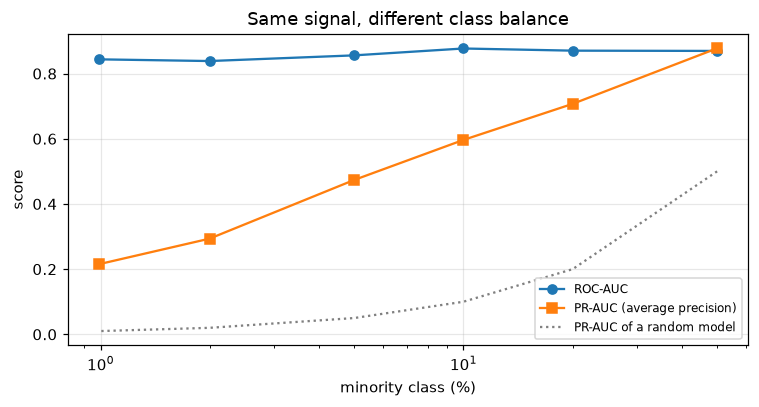


ROC-AUC is essentially FLAT: 0.8695 at 50% positives, 0.8437 at 1%.
PR-AUC collapses: 0.8775 -> 0.2152.

Both are telling the truth about different things. ROC says the model's RANKING is
just as good - and it is. PR says that if you actually deploy this and act on the
flagged rows, most of them will be wrong - and they will be.

Read the last column before despairing at the PR number, though. A PR-AUC of 0.22 at
a 1% base rate is a 22x lift over random. The raw value looks terrible and the model
is doing a great deal of work. Always compare PR-AUC against the positive RATE, which
is what a random model scores.


In [4]:
# Generate ONE balanced dataset, then subsample the positives. The signal is identical in
# every row, so any change in the metrics is caused only by the class balance.
X_full, y_full = make_classification(n_samples=20000, n_features=20, n_informative=6,
                                     n_redundant=4, weights=[0.5, 0.5], flip_y=0.01,
                                     class_sep=0.8, random_state=RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)
neg_idx = np.where(y_full == 0)[0]
pos_idx = np.where(y_full == 1)[0]
n_neg = 8000
neg_keep = rng.choice(neg_idx, n_neg, replace=False)

print("The SAME underlying signal at every imbalance level.\n")
print(f"{'minority %':>12} {'positives':>11} {'ROC-AUC':>9} {'PR-AUC':>9} "
      f"{'PR baseline':>13} {'lift':>7}")
print("-" * 68)
rates, rocs, prs = [], [], []
for rate in [0.50, 0.20, 0.10, 0.05, 0.02, 0.01]:
    n_pos = int(n_neg * rate / (1 - rate))
    pos_keep = rng.choice(pos_idx, min(n_pos, len(pos_idx)), replace=False)
    idx = np.concatenate([neg_keep, pos_keep])
    Xi, yi = X_full[idx], y_full[idx]
    m = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=3000))])
    p = cross_val_predict(m, Xi, yi, cv=SKF, method="predict_proba")[:, 1]
    roc, ap = roc_auc_score(yi, p), average_precision_score(yi, p)
    rates.append(yi.mean()); rocs.append(roc); prs.append(ap)
    print(f"{yi.mean():>11.2%} {int(yi.sum()):>11} {roc:>9.4f} {ap:>9.4f} "
          f"{yi.mean():>13.4f} {ap / yi.mean():>6.1f}x")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot([r * 100 for r in rates], rocs, marker="o", label="ROC-AUC")
ax.plot([r * 100 for r in rates], prs, marker="s", label="PR-AUC (average precision)")
ax.plot([r * 100 for r in rates], rates, ls=":", color="gray",
        label="PR-AUC of a random model")
ax.set(xlabel="minority class (%)", ylabel="score",
       title="Same signal, different class balance")
ax.set_xscale("log"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print()
print(f"ROC-AUC is essentially FLAT: {rocs[0]:.4f} at 50% positives, {rocs[-1]:.4f} at 1%.")
print(f"PR-AUC collapses: {prs[0]:.4f} -> {prs[-1]:.4f}.")
print()
print("Both are telling the truth about different things. ROC says the model's RANKING is")
print("just as good - and it is. PR says that if you actually deploy this and act on the")
print("flagged rows, most of them will be wrong - and they will be.")
print()
print("Read the last column before despairing at the PR number, though. A PR-AUC of 0.22 at")
print("a 1% base rate is a 22x lift over random. The raw value looks terrible and the model")
print("is doing a great deal of work. Always compare PR-AUC against the positive RATE, which")
print("is what a random model scores.")

## 1.3 The three levers

Everything people do about imbalance is one of these:

1. **Class weights** — tell the loss function that a minority error costs more.
   `class_weight="balanced"` sets the weight inversely proportional to class frequency. No data
   is changed.
2. **Resampling** — change the training data. Oversample the minority (duplicate rows, or
   synthesise new ones with SMOTE), undersample the majority (throw rows away), or both.
3. **Threshold moving** — leave the model and the data alone, and predict positive above some
   probability other than 0.5.

They are more similar than they look. Weighting a class by $w$ and duplicating its rows $w$
times give the same gradient for many losses; and both mostly shift *where the model draws the
line*, which is exactly what lever 3 does directly.

In [5]:
print("The three levers on the same data and the same model.\n")
print(f"{'lever':<44} {'PR-AUC':>9} {'ROC-AUC':>9} {'recall':>8} {'F1':>8}")
print("-" * 82)
for name, model in [
    ("nothing (baseline)",
     Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=3000))])),
    ("1. class_weight='balanced'",
     Pipeline([("sc", StandardScaler()),
               ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])),
    ("2a. random oversampling",
     ImbPipeline([("sc", StandardScaler()), ("os", RandomOverSampler(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
    ("2b. random undersampling",
     ImbPipeline([("sc", StandardScaler()), ("us", RandomUnderSampler(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
    ("2c. SMOTE",
     ImbPipeline([("sc", StandardScaler()), ("sm", SMOTE(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
]:
    r = cross_validate(model, X, y, cv=SKF,
                       scoring={k: SCORING[k] for k in
                                ["average_precision", "roc_auc", "recall", "f1"]})
    print(f"{name:<44} {r['test_average_precision'].mean():>9.4f} "
          f"{r['test_roc_auc'].mean():>9.4f} {r['test_recall'].mean():>8.4f} "
          f"{r['test_f1'].mean():>8.4f}")

print()
print("Read the columns separately, because they disagree.")
print()
print("  RECALL jumps from 0.00 to about 0.6-0.7 under every treatment. That is what people")
print("  see, and it is why resampling feels like it works.")
print()
print("  PR-AUC and ROC-AUC barely move, and the BASELINE has the best PR-AUC of the five.")
print("  The ranking of rows by risk is essentially unchanged.")
print()
print("That combination is the central fact of this notebook. The treatments did not find")
print("more signal - they moved the operating point along a trade-off the untouched model")
print("already contained. 1.6 makes that literal.")
print()
print("Lever 3 - the threshold - is not in this table because it needs no separate model.")
print("It is the same baseline row, read at a different cut-off.")

The three levers on the same data and the same model.

lever                                           PR-AUC   ROC-AUC   recall       F1
----------------------------------------------------------------------------------
nothing (baseline)                              0.0870    0.7176   0.0000   0.0000
1. class_weight='balanced'                      0.0758    0.7245   0.6000   0.0580
2a. random oversampling                         0.0779    0.7254   0.6000   0.0590
2b. random undersampling                        0.0579    0.7170   0.7375   0.0624
2c. SMOTE                                       0.0805    0.7207   0.5875   0.0580

Read the columns separately, because they disagree.

  RECALL jumps from 0.00 to about 0.6-0.7 under every treatment. That is what people
  see, and it is why resampling feels like it works.

  PR-AUC and ROC-AUC barely move, and the BASELINE has the best PR-AUC of the five.
  The ranking of rows by risk is essentially unchanged.

That combination is the centra

## 1.4 SMOTE from scratch

**Synthetic Minority Over-sampling TEchnique** (Chawla et al., 2002). Rather than duplicating
minority rows, invent new ones:

1. Pick a minority point $x$.
2. Pick one of its $k$ nearest *minority* neighbours, $x'$.
3. Create a new point somewhere on the segment between them:
   $x_{\text{new}} = x + \lambda(x' - x)$ with $\lambda \sim U(0,1)$.

Repeat until the classes are balanced. The whole method is four lines, and writing it makes its
limits obvious in a way the API does not.

In [6]:
def smote_from_scratch(X, y, k=5, seed=0):
    """Interpolate new minority points toward a random minority neighbour."""
    rng = np.random.default_rng(seed)
    X_min = X[y == 1]
    n_needed = int((y == 0).sum() - (y == 1).sum())

    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    neighbours = nn.kneighbors(X_min, return_distance=False)[:, 1:]     # drop self

    base = rng.integers(0, len(X_min), n_needed)                        # which point
    partner = neighbours[base, rng.integers(0, k, n_needed)]            # which neighbour
    lam = rng.random((n_needed, X.shape[1]))                            # how far along
    synthetic = X_min[base] + lam * (X_min[partner] - X_min[base])

    return (np.vstack([X, synthetic]),
            np.concatenate([y, np.ones(n_needed, dtype=y.dtype)]))


Xs, ys = make_classification(n_samples=2000, n_features=10, n_informative=5, n_redundant=0,
                             weights=[0.95, 0.05], class_sep=1.0, random_state=RANDOM_STATE)
X_mine, y_mine = smote_from_scratch(Xs, ys, k=5, seed=RANDOM_STATE)
X_lib, y_lib = SMOTE(random_state=RANDOM_STATE, k_neighbors=5).fit_resample(Xs, ys)

print(f"original       : {Xs.shape[0]:>5} rows, {int(ys.sum()):>4} positives ({ys.mean():.1%})")
print(f"mine           : {X_mine.shape[0]:>5} rows, {int(y_mine.sum()):>4} positives "
      f"({y_mine.mean():.1%})")
print(f"imblearn SMOTE : {X_lib.shape[0]:>5} rows, {int(y_lib.sum()):>4} positives "
      f"({y_lib.mean():.1%})")

synthetic = X_mine[len(Xs):]
X_min = Xs[ys == 1]
d, _ = NearestNeighbors(n_neighbors=1).fit(X_min).kneighbors(synthetic)
print(f"\nsynthetic points identical to a real one : {(d.ravel() < 1e-12).sum()} of {len(synthetic)}")
print(f"mean distance to the nearest real minority point : {d.mean():.4f}")
print()
print("Two properties follow directly from the construction, and they explain everything in")
print("1.5 and 1.7:")
print()
print("  1. Every synthetic point lies INSIDE the convex hull of the minority points you")
print("     already have. SMOTE cannot invent minority structure in a region where you have")
print("     no minority examples - it can only fill in between the ones you do.")
print()
print("  2. It uses NEAREST NEIGHBOURS, so it inherits every property of NB-07: it needs")
print("     scaled features, and it degrades when distances stop being meaningful.")

original       :  2000 rows,  107 positives (5.3%)
mine           :  3786 rows, 1893 positives (50.0%)
imblearn SMOTE :  3786 rows, 1893 positives (50.0%)

synthetic points identical to a real one : 0 of 1786
mean distance to the nearest real minority point : 1.3014

Two properties follow directly from the construction, and they explain everything in
1.5 and 1.7:

  1. Every synthetic point lies INSIDE the convex hull of the minority points you
     already have. SMOTE cannot invent minority structure in a region where you have
     no minority examples - it can only fill in between the ones you do.

  2. It uses NEAREST NEIGHBOURS, so it inherits every property of NB-07: it needs
     scaled features, and it degrades when distances stop being meaningful.


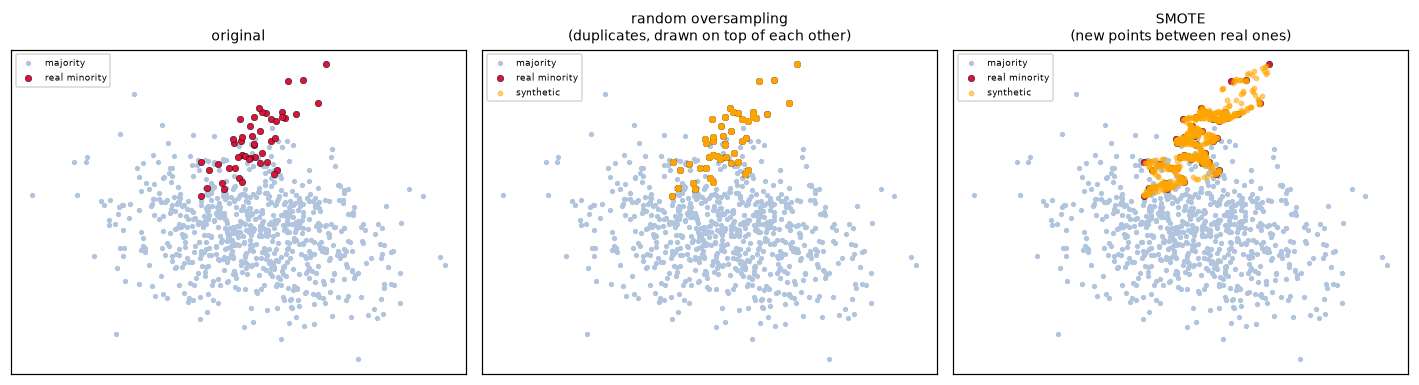

original minority points : 48
after SMOTE              : 752 (704 synthetic)

Random oversampling adds no new locations - the duplicates sit exactly on top of the
originals, which is why the middle panel looks unchanged. SMOTE spreads the minority
class over the region BETWEEN its existing points.

Look at where the orange points go relative to the blue ones. That is 1.5's subject.


In [7]:
# What it looks like.
X2, y2 = make_classification(n_samples=800, n_features=2, n_informative=2, n_redundant=0,
                             n_clusters_per_class=1, weights=[0.94, 0.06], class_sep=1.1,
                             flip_y=0.0, random_state=RANDOM_STATE)
X2r, y2r = SMOTE(random_state=RANDOM_STATE).fit_resample(X2, y2)
X2u, y2u = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X2, y2)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (title, Xp, yp, n_orig) in zip(axes, [
        ("original", X2, y2, len(X2)),
        ("random oversampling\n(duplicates, drawn on top of each other)", X2u, y2u, len(X2)),
        ("SMOTE\n(new points between real ones)", X2r, y2r, len(X2))]):
    ax.scatter(Xp[yp == 0][:, 0], Xp[yp == 0][:, 1], s=6, c="lightsteelblue", label="majority")
    ax.scatter(Xp[:n_orig][yp[:n_orig] == 1][:, 0], Xp[:n_orig][yp[:n_orig] == 1][:, 1],
               s=18, c="crimson", edgecolor="k", lw=0.3, label="real minority")
    if len(Xp) > n_orig:
        ax.scatter(Xp[n_orig:][:, 0], Xp[n_orig:][:, 1], s=8, c="orange", alpha=0.5,
                   label="synthetic")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=6, loc="upper left")
fig.tight_layout(); plt.show()

print(f"original minority points : {int(y2.sum())}")
print(f"after SMOTE              : {int(y2r.sum())} "
      f"({int(y2r.sum() - y2.sum())} synthetic)")
print()
print("Random oversampling adds no new locations - the duplicates sit exactly on top of the")
print("originals, which is why the middle panel looks unchanged. SMOTE spreads the minority")
print("class over the region BETWEEN its existing points.")
print()
print("Look at where the orange points go relative to the blue ones. That is 1.5's subject.")

## 1.5 Where interpolation goes wrong

SMOTE draws a straight line between two minority points and puts a new minority point on it.
That is only sound if the whole segment really is minority territory.

Two situations where it is not, and one that is more conditional than usually claimed.

In [8]:
print("A. OVERLAPPING CLASSES - the segment crosses into majority territory\n")
print(f"  {'class_sep':>10} {'baseline PR-AUC':>17} {'SMOTE PR-AUC':>14} {'delta':>9}")
print("  " + "-" * 54)
for sep in [2.0, 1.0, 0.5]:
    Xo, yo = make_classification(n_samples=3000, n_features=10, n_informative=5,
                                 n_redundant=0, weights=[0.97, 0.03], class_sep=sep,
                                 flip_y=0.0, random_state=RANDOM_STATE)
    b = cross_validate(Pipeline([("sc", StandardScaler()),
                                 ("clf", LogisticRegression(max_iter=3000))]),
                       Xo, yo, cv=SKF, scoring=["average_precision"])
    s = cross_validate(ImbPipeline([("sc", StandardScaler()),
                                    ("sm", SMOTE(random_state=RANDOM_STATE)),
                                    ("clf", LogisticRegression(max_iter=3000))]),
                       Xo, yo, cv=SKF, scoring=["average_precision"])
    bm, sm_ = b["test_average_precision"].mean(), s["test_average_precision"].mean()
    print(f"  {sep:>10.1f} {bm:>17.4f} {sm_:>14.4f} {sm_ - bm:>+9.4f}")

print()
print("  SMOTE costs PR-AUC at every separation, and the cost grows as the classes overlap -")
print("  because that is when the line between two minority points is most likely to pass")
print("  through a region that is actually majority.")
print()
print("  BorderlineSMOTE and ADASYN exist to address exactly this, by synthesising only near")
print("  the decision boundary or preferentially in hard regions:")
Xo, yo = make_classification(n_samples=3000, n_features=10, n_informative=5,
                             n_redundant=0, weights=[0.97, 0.03], class_sep=1.0,
                             flip_y=0.0, random_state=RANDOM_STATE)
base_ap = cross_validate(Pipeline([("sc", StandardScaler()),
                                   ("clf", LogisticRegression(max_iter=3000))]),
                         Xo, yo, cv=SKF,
                         scoring=["average_precision"])["test_average_precision"].mean()
for name, sampler in [("SMOTE", SMOTE(random_state=RANDOM_STATE)),
                      ("BorderlineSMOTE", BorderlineSMOTE(random_state=RANDOM_STATE)),
                      ("ADASYN", ADASYN(random_state=RANDOM_STATE)),
                      ("SMOTETomek (clean up after)", SMOTETomek(random_state=RANDOM_STATE))]:
    r = cross_validate(ImbPipeline([("sc", StandardScaler()), ("sm", sampler),
                                    ("clf", LogisticRegression(max_iter=3000))]),
                       Xo, yo, cv=SKF, scoring=["average_precision"])
    print(f"    {name:<30} {r['test_average_precision'].mean():.4f}")
print(f"    {'(baseline, no resampling)':<30} {base_ap:.4f}")
print()
print("  None of the boundary-aware variants recovered the baseline here.")

A. OVERLAPPING CLASSES - the segment crosses into majority territory

   class_sep   baseline PR-AUC   SMOTE PR-AUC     delta
  ------------------------------------------------------
         2.0            0.7418         0.7287   -0.0131
         1.0            0.4460         0.3736   -0.0724
         0.5            0.2469         0.1739   -0.0730

  SMOTE costs PR-AUC at every separation, and the cost grows as the classes overlap -
  because that is when the line between two minority points is most likely to pass
  through a region that is actually majority.

  BorderlineSMOTE and ADASYN exist to address exactly this, by synthesising only near
  the decision boundary or preferentially in hard regions:
    SMOTE                          0.3736
    BorderlineSMOTE                0.3672
    ADASYN                         0.3819
    SMOTETomek (clean up after)    0.3736
    (baseline, no resampling)      0.4460

  None of the boundary-aware variants recovered the baseline here.


In [9]:
print("B. CATEGORICAL FEATURES - averaging two categories invents a third\n")
print("  The usual warning is 'never use SMOTE on categorical data'. That is directionally")
print("  right but the mechanism is worth knowing, because it tells you WHEN it bites.\n")

def categorical_demo(n_numeric, n_levels=4, n=3000, seed=RANDOM_STATE):
    """One categorical column encoded 0..n_levels-1, plus n_numeric numeric columns."""
    r = np.random.default_rng(seed)
    cat = r.integers(0, n_levels, n).astype(float)
    num = r.normal(size=(n, n_numeric))
    y_ = (np.isin(cat, [1, 3]) & (num[:, 0] > 1.0)).astype(int)
    return np.column_stack([cat, num]), y_, cat


print(f"  {'numeric cols':>13} {'same-category neighbours':>26} {'invalid synthetic cats':>24}")
print("  " + "-" * 66)
for n_num in [1, 3, 10, 30, 100]:
    Xc, yc, cat = categorical_demo(n_num)
    Xc_s = StandardScaler().fit(Xc)
    Xmin = Xc_s.transform(Xc)[yc == 1]
    cmin = cat[yc == 1]
    k = min(5, len(Xmin) - 1)
    nb = NearestNeighbors(n_neighbors=k + 1).fit(Xmin).kneighbors(
        Xmin, return_distance=False)[:, 1:]
    same = np.mean([(cmin[nb[i]] == cmin[i]).mean() for i in range(len(Xmin))])
    Xr, _ = SMOTE(random_state=RANDOM_STATE, k_neighbors=k).fit_resample(
        Xc_s.transform(Xc), yc)
    synth = Xc_s.inverse_transform(Xr[len(Xc):])[:, 0]
    invalid = (~np.isin(np.round(synth, 6), np.arange(4.0))).mean()
    print(f"  {n_num:>13} {same:>25.1%} {invalid:>23.1%}")

print()
print("  With one categorical column and a few numeric ones, the category dominates the")
print("  distance: a point's nearest minority neighbours almost always share its category,")
print("  so interpolating returns that category unchanged and NOTHING BREAKS.")
print()
print("  As numeric columns pile up, the category becomes a smaller share of the distance,")
print("  neighbours stop matching, and interpolation starts producing values BETWEEN levels -")
print("  'category 2.4', which does not exist.")
print()
print("  So the real rule is: SMOTE corrupts a categorical column exactly when that column is")
print("  a small part of the distance. Many numeric features does it; so do many levels:")
for n_levels in [4, 20, 50]:
    r = np.random.default_rng(RANDOM_STATE)
    n = 3000
    cat = r.integers(0, n_levels, n).astype(float)
    num = r.normal(size=(n, 30))
    yy = ((cat % 2 == 1) & (num[:, 0] > 1.0)).astype(int)
    XX = np.column_stack([cat, num])
    sc = StandardScaler().fit(XX)
    Xr, _ = SMOTE(random_state=RANDOM_STATE).fit_resample(sc.transform(XX), yy)
    synth = sc.inverse_transform(Xr[len(XX):])[:, 0]
    inval = (~np.isin(np.round(synth, 6), np.arange(float(n_levels)))).mean()
    print(f"    {n_levels:>2} levels, 30 numeric columns -> {inval:>5.1%} invalid")

print()
print("  The fix is SMOTENC, which resamples categorical columns by majority VOTE among the")
print("  neighbours instead of averaging:")
Xc, yc, _ = categorical_demo(30)
Xn, _ = SMOTENC(categorical_features=[0], random_state=RANDOM_STATE).fit_resample(Xc, yc)
sc_vals = Xn[len(Xc):, 0].astype(float)
print(f"    SMOTENC synthetic category values all valid: "
      f"{bool(np.isin(np.round(sc_vals, 6), np.arange(4.0)).all())}")

B. CATEGORICAL FEATURES - averaging two categories invents a third

  The usual warning is 'never use SMOTE on categorical data'. That is directionally
  right but the mechanism is worth knowing, because it tells you WHEN it bites.

   numeric cols   same-category neighbours   invalid synthetic cats
  ------------------------------------------------------------------
              1                    100.0%                    0.0%
              3                    100.0%                    0.0%
             10                     90.9%                    9.4%
             30                     69.5%                   29.6%
            100                     59.2%                   41.8%

  With one categorical column and a few numeric ones, the category dominates the
  distance: a point's nearest minority neighbours almost always share its category,
  so interpolating returns that category unchanged and NOTHING BREAKS.

  As numeric columns pile up, the category becomes a smaller s

## 1.6 Threshold moving does the same job, for free

Levers 1 and 2 change the model so that its 0.5 cut-off lands somewhere useful. Lever 3 leaves
the model alone and moves the cut-off.

The second is strictly more flexible: one fitted model gives you *every* operating point, you
can change it after deployment without retraining, and it does not touch your probabilities
(§1.8).

ONE model, no resampling, no class weights. Only the threshold changes.

   threshold   precision    recall       F1   flagged
  ----------------------------------------------------
        0.50      0.0000    0.0000   0.0000         1
        0.20      0.2857    0.0250   0.0460         7
        0.10      0.1316    0.0625   0.0847        38
        0.05      0.0657    0.1750   0.0956       213
        0.03      0.0417    0.3375   0.0742       648
        0.02      0.0355    0.5250   0.0666      1182
        0.01      0.0246    0.7750   0.0477      2518

  best-F1 threshold 0.0755: precision 0.1310  recall 0.1375  F1 0.1341

approach                                          PR-AUC       F1    recall
----------------------------------------------------------------------------
no resampling + tuned threshold                   0.0628   0.1341    0.1375
SMOTE, default threshold 0.5                      0.0588   0.0581    0.5875
class_weight='balanced', threshold 0.5            0.0522   0.0

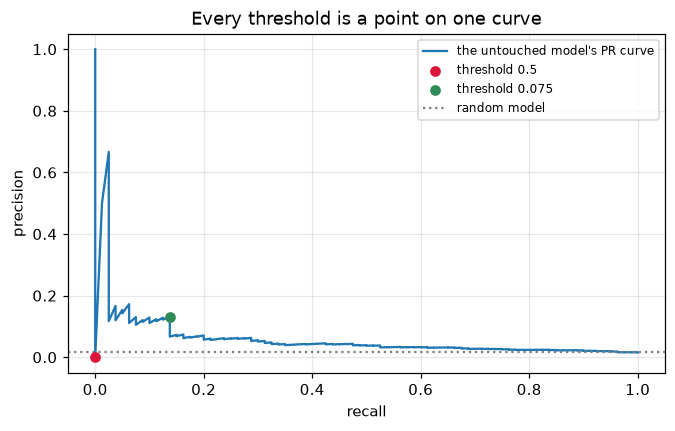


The tuned threshold beats both resampling methods on F1, more than doubling them -
using a model that was never told the classes were imbalanced.

The picture explains why. Resampling does not lift the PR curve; it slides you along
it. The threshold slides you along the same curve, without a second fit, without
discarding data, and without breaking calibration.


In [10]:
base = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=3000))])
proba = cross_val_predict(base, X, y, cv=SKF, method="predict_proba")[:, 1]

print("ONE model, no resampling, no class weights. Only the threshold changes.\n")
print(f"  {'threshold':>10} {'precision':>11} {'recall':>9} {'F1':>8} {'flagged':>9}")
print("  " + "-" * 52)
for t in [0.50, 0.20, 0.10, 0.05, 0.03, 0.02, 0.01]:
    pred = (proba >= t).astype(int)
    if pred.sum() == 0:
        continue
    print(f"  {t:>10.2f} {precision_score(y, pred, zero_division=0):>11.4f} "
          f"{recall_score(y, pred, zero_division=0):>9.4f} {f1_score(y, pred, zero_division=0):>8.4f} {pred.sum():>9}")

grid = np.linspace(0.002, 0.7, 400)
best_t = max(grid, key=lambda t: f1_score(y, (proba >= t).astype(int)))
best_pred = (proba >= best_t).astype(int)
print(f"\n  best-F1 threshold {best_t:.4f}: precision "
      f"{precision_score(y, best_pred, zero_division=0):.4f}  recall {recall_score(y, best_pred, zero_division=0):.4f}  "
      f"F1 {f1_score(y, best_pred, zero_division=0):.4f}")

print(f"\n{'approach':<46} {'PR-AUC':>9} {'F1':>8} {'recall':>9}")
print("-" * 76)
print(f"{'no resampling + tuned threshold':<46} {average_precision_score(y, proba):>9.4f} "
      f"{f1_score(y, best_pred, zero_division=0):>8.4f} {recall_score(y, best_pred, zero_division=0):>9.4f}")
for name, model in [
    ("SMOTE, default threshold 0.5",
     ImbPipeline([("sc", StandardScaler()), ("sm", SMOTE(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
    ("class_weight='balanced', threshold 0.5",
     Pipeline([("sc", StandardScaler()),
               ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])),
]:
    pr = cross_val_predict(model, X, y, cv=SKF, method="predict_proba")[:, 1]
    pd_ = (pr >= 0.5).astype(int)
    print(f"{name:<46} {average_precision_score(y, pr):>9.4f} "
          f"{f1_score(y, pd_, zero_division=0):>8.4f} {recall_score(y, pd_, zero_division=0):>9.4f}")

prec, rec, _ = precision_recall_curve(y, proba)
plt.plot(rec, prec, label="the untouched model's PR curve")
plt.scatter([recall_score(y, (proba >= 0.5).astype(int))],
            [precision_score(y, (proba >= 0.5).astype(int), zero_division=0)],
            color="crimson", zorder=5, label="threshold 0.5")
plt.scatter([recall_score(y, best_pred, zero_division=0)], [precision_score(y, best_pred, zero_division=0)],
            color="seagreen", zorder=5, label=f"threshold {best_t:.3f}")
plt.axhline(y.mean(), ls=":", color="gray", label="random model")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("Every threshold is a point on one curve")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print()
print("The tuned threshold beats both resampling methods on F1, more than doubling them -")
print("using a model that was never told the classes were imbalanced.")
print()
print("The picture explains why. Resampling does not lift the PR curve; it slides you along")
print("it. The threshold slides you along the same curve, without a second fit, without")
print("discarding data, and without breaking calibration.")

## 1.7 Does resampling help at all?

§1.3 and §1.6 both suggest not. Rather than generalise from one dataset, sweep the conditions
under which it is supposed to help: class separation, dimensionality, and imbalance ratio.

In [11]:
def compare(Xd, yd, label):
    """Baseline vs SMOTE on PR-AUC, both inside a proper pipeline."""
    b = cross_validate(Pipeline([("sc", StandardScaler()),
                                 ("clf", LogisticRegression(max_iter=3000))]),
                       Xd, yd, cv=SKF, scoring=["average_precision"])
    s = cross_validate(ImbPipeline([("sc", StandardScaler()),
                                    ("sm", SMOTE(random_state=RANDOM_STATE)),
                                    ("clf", LogisticRegression(max_iter=3000))]),
                       Xd, yd, cv=SKF, scoring=["average_precision"])
    bm, sm_ = b["test_average_precision"].mean(), s["test_average_precision"].mean()
    print(f"  {label:<28} {bm:>10.4f} {sm_:>9.4f} {sm_ - bm:>+9.4f}")
    return sm_ - bm


deltas = []
print(f"  {'condition':<28} {'baseline':>10} {'SMOTE':>9} {'delta':>9}")
print("  " + "-" * 60)
print("  varying DIMENSIONALITY:")
for p in [10, 50, 200, 1000]:
    Xd, yd = make_classification(n_samples=2000, n_features=p, n_informative=8,
                                 n_redundant=0, weights=[0.97, 0.03], class_sep=1.0,
                                 random_state=RANDOM_STATE)
    deltas.append(compare(Xd, yd, f"    {p} features"))

print("  varying IMBALANCE:")
for w in [0.30, 0.10, 0.05, 0.02, 0.01]:
    Xd, yd = make_classification(n_samples=4000, n_features=20, n_informative=8,
                                 n_redundant=0, weights=[1 - w, w], class_sep=1.0,
                                 random_state=RANDOM_STATE)
    deltas.append(compare(Xd, yd, f"    {w:.0%} minority"))

print("  varying SEPARATION:")
for sep in [0.5, 1.0, 2.0]:
    Xd, yd = make_classification(n_samples=3000, n_features=10, n_informative=5,
                                 n_redundant=0, weights=[0.97, 0.03], class_sep=sep,
                                 flip_y=0.0, random_state=RANDOM_STATE)
    deltas.append(compare(Xd, yd, f"    class_sep={sep}"))

deltas = np.array(deltas)
print(f"\n  configurations tested          : {len(deltas)}")
print(f"  where SMOTE improved PR-AUC    : {(deltas > 0).sum()}")
print(f"  where SMOTE reduced PR-AUC     : {(deltas < 0).sum()}")
print(f"  mean change                    : {deltas.mean():+.4f}")
print(f"  worst change                   : {deltas.min():+.4f}")
print()
print("That is a consistent result, not a cherry-picked one. Across every axis SMOTE is")
print("supposed to help along, it did not improve the model's ability to RANK rows by risk.")
print()
print("Be precise about the claim, though. This says resampling does not add information -")
print("it cannot, since it invents no new observations. It does NOT say resampling never")
print("changes anything useful: it reliably raises recall at a fixed threshold (1.3), and")
print("that is genuinely what some people need. The point is that threshold moving gives you")
print("the same thing more cheaply and more reversibly (1.6).")
print()
print("Where resampling still earns its place: when a learner cannot take class weights or")
print("a custom threshold at all, when undersampling makes an intractably large dataset")
print("trainable, or when a downstream system demands a balanced training set.")

  condition                      baseline     SMOTE     delta
  ------------------------------------------------------------
  varying DIMENSIONALITY:
      10 features                  0.3067    0.2105   -0.0962
      50 features                  0.2552    0.1644   -0.0908
      200 features                 0.1062    0.1055   -0.0007
      1000 features                0.0503    0.0531   +0.0029
  varying IMBALANCE:
      30% minority                 0.7170    0.7079   -0.0091
      10% minority                 0.4724    0.4061   -0.0663
      5% minority                  0.3454    0.2633   -0.0822
      2% minority                  0.2422    0.1715   -0.0708
      1% minority                  0.1398    0.0813   -0.0585
  varying SEPARATION:
      class_sep=0.5                0.2469    0.1739   -0.0730
      class_sep=1.0                0.4460    0.3736   -0.0724
      class_sep=2.0                0.7418    0.7287   -0.0131

  configurations tested          : 12
  where SMOTE improved 

## 1.8 What resampling does to your probabilities

A model learns $P(y \mid x)$ *for the distribution it was trained on*. Change the class balance
and you change that distribution — so the probabilities come out calibrated to a world in which
the positive class is far commoner than it really is.

In [12]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y,
                                      random_state=RANDOM_STATE)
print(f"true positive rate in the test set: {yte.mean():.4f}\n")
print(f"{'model':<44} {'Brier':>9} {'log-loss':>10} {'mean predicted P':>18}")
print("-" * 84)
for name, model in [
    ("no resampling", Pipeline([("sc", StandardScaler()),
                                ("clf", LogisticRegression(max_iter=3000))])),
    ("class_weight='balanced'",
     Pipeline([("sc", StandardScaler()),
               ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])),
    ("SMOTE", ImbPipeline([("sc", StandardScaler()), ("sm", SMOTE(random_state=RANDOM_STATE)),
                           ("clf", LogisticRegression(max_iter=3000))])),
    ("random undersampling",
     ImbPipeline([("sc", StandardScaler()), ("us", RandomUnderSampler(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
]:
    model.fit(Xtr, ytr)
    p = model.predict_proba(Xte)[:, 1]
    print(f"{name:<44} {brier_score_loss(yte, p):>9.4f} {log_loss(yte, p):>10.4f} "
          f"{p.mean():>18.4f}")

print()
print("A calibrated model's mean predicted probability should match the true positive rate.")
print("The untouched model does that almost exactly. Every treatment lands an order of")
print("magnitude too high, and Brier and log-loss both degrade by a factor of five or more.")
print()
print("This matters whenever the NUMBER is used, not just the ranking:")
print("  - expected-value calculations ('flag it if P(fraud) x amount > review cost')")
print("  - risk scores shown to a human")
print("  - anything feeding a downstream model or a threshold chosen from costs (3.2)")
print()
print("If you must resample and you need probabilities, recalibrate afterwards on data with")
print("the ORIGINAL class balance - CalibratedClassifierCV, as in NB-00 section 7 - or use")
print("the analytic prior correction (Q7). Or, more simply, do not resample: 1.6 showed the")
print("threshold gives you the same operating point with the calibration intact.")

true positive rate in the test set: 0.0160

model                                            Brier   log-loss   mean predicted P
------------------------------------------------------------------------------------
no resampling                                   0.0157     0.0810             0.0168
class_weight='balanced'                         0.1990     0.5831             0.3947
SMOTE                                           0.1930     0.5721             0.3700
random undersampling                            0.2272     0.6582             0.4101

A calibrated model's mean predicted probability should match the true positive rate.
The untouched model does that almost exactly. Every treatment lands an order of
magnitude too high, and Brier and log-loss both degrade by a factor of five or more.

This matters whenever the NUMBER is used, not just the ranking:
  - expected-value calculations ('flag it if P(fraud) x amount > review cost')
  - risk scores shown to a human
  - anything feedi

***
# Part 2 - Worked example: mammography screening

**The task.** 11,183 regions of interest extracted from digitised mammograms, described by six
shape and intensity features. **2.3%** contain a microcalcification — an early marker of breast
cancer. Find them.

**Why this dataset.** Everything about it is real: the imbalance, the difficulty, and above all
the **cost asymmetry**. A missed microcalcification is a missed cancer. A false alarm is a
follow-up scan. Those are not remotely equal, and §3.2 uses that to choose the threshold.

## 2.1 Look at the problem before modelling it

samples            : 11,183
features           : 6
positives          : 260 (2.325%)
imbalance ratio    : 42 negatives per positive

what a do-nothing model achieves:
  accuracy             0.9768
  recall               0.0000
  average_precision    0.0232

  So 'accuracy above 97%' is the FLOOR here, not an achievement. And the PR-AUC
  floor is the positive rate itself, 0.0232 - that is the number any real
  model has to beat.


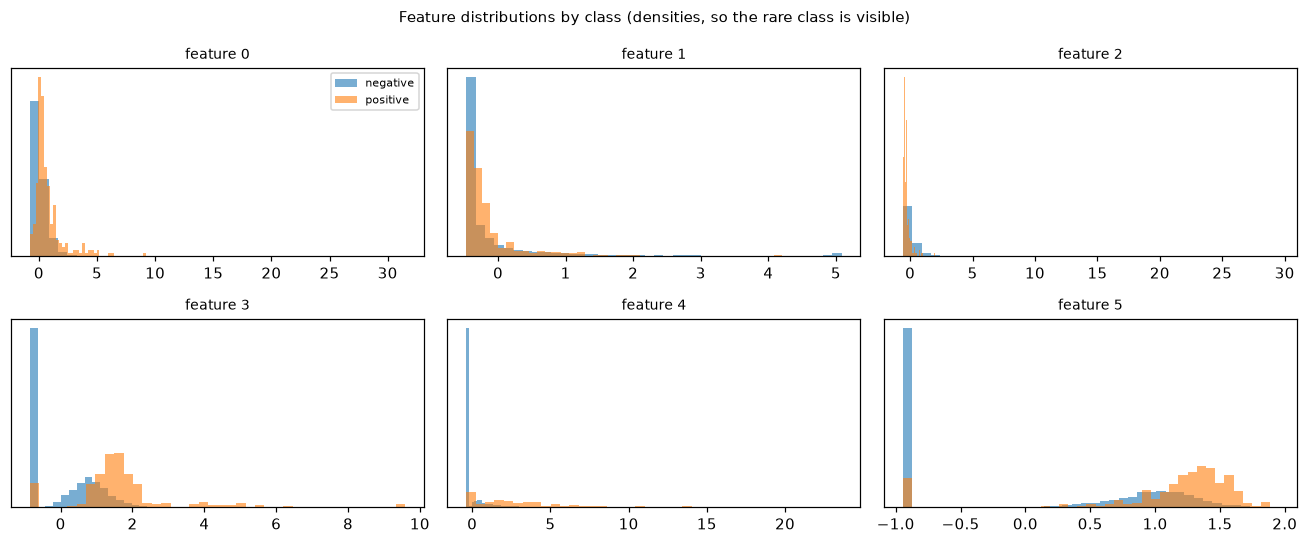

Plotting DENSITIES rather than counts is not cosmetic - at 2.3% positives, a count
histogram shows a flat line where the minority class is. It is the same problem
accuracy has, in a chart.


In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")           # the fetcher chats on first download
    mam = fetch_datasets()["mammography"]

Xm = np.asarray(mam.data)
ym = (np.asarray(mam.target) == 1).astype(int)

print(f"samples            : {Xm.shape[0]:,}")
print(f"features           : {Xm.shape[1]}")
print(f"positives          : {ym.sum()} ({ym.mean():.3%})")
print(f"imbalance ratio    : {(1 - ym.mean()) / ym.mean():.0f} negatives per positive")

print(f"\nwhat a do-nothing model achieves:")
dm = DummyClassifier(strategy="most_frequent")
r = cross_validate(dm, Xm, ym, cv=SKF,
                   scoring={k: SCORING[k] for k in
                            ["accuracy", "recall", "average_precision"]})
for k in ["accuracy", "recall", "average_precision"]:
    print(f"  {k:<20} {r['test_' + k].mean():.4f}")
print(f"\n  So 'accuracy above 97%' is the FLOOR here, not an achievement. And the PR-AUC")
print(f"  floor is the positive rate itself, {ym.mean():.4f} - that is the number any real")
print(f"  model has to beat.")

fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.hist(Xm[ym == 0][:, i], bins=40, alpha=0.6, density=True, label="negative")
    ax.hist(Xm[ym == 1][:, i], bins=40, alpha=0.6, density=True, label="positive")
    ax.set_title(f"feature {i}", fontsize=9)
    ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=7)
fig.suptitle("Feature distributions by class (densities, so the rare class is visible)",
             fontsize=10)
fig.tight_layout(); plt.show()

print("Plotting DENSITIES rather than counts is not cosmetic - at 2.3% positives, a count")
print("histogram shows a flat line where the minority class is. It is the same problem")
print("accuracy has, in a chart.")

## 2.2 A baseline, measured properly

In [14]:
base_m = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=3000))])
p_base = cross_val_predict(base_m, Xm, ym, cv=SKF, method="predict_proba")[:, 1]

print(f"untreated logistic regression:")
print(f"  accuracy         {accuracy_score(ym, (p_base >= 0.5).astype(int)):.4f}   "
      f"<- barely above the do-nothing floor")
print(f"  ROC-AUC          {roc_auc_score(ym, p_base):.4f}")
print(f"  PR-AUC           {average_precision_score(ym, p_base):.4f}   "
      f"<- vs a floor of {ym.mean():.4f}, a {average_precision_score(ym, p_base)/ym.mean():.0f}x lift")
print(f"  recall @ 0.5     {recall_score(ym, (p_base >= 0.5).astype(int)):.4f}")
print(f"  precision @ 0.5  {precision_score(ym, (p_base >= 0.5).astype(int)):.4f}")

cm = confusion_matrix(ym, (p_base >= 0.5).astype(int))
print("\nconfusion matrix at the default threshold:")
print(pd.DataFrame(cm, index=["true negative", "true POSITIVE"],
                   columns=["pred negative", "pred POSITIVE"]).to_string())
tn, fp, fn, tp = cm.ravel()
print(f"\n  caught {tp} of {tp + fn} microcalcifications; missed {fn}")
print(f"  raised {fp} false alarms")
print()
print("Report it this way - in counts of the thing you care about - rather than as a single")
print("score. 'We miss 4 in 10' is a sentence a radiologist can respond to; '0.61 PR-AUC'")
print("is not.")

untreated logistic regression:
  accuracy         0.9836   <- barely above the do-nothing floor
  ROC-AUC          0.9151
  PR-AUC           0.6125   <- vs a floor of 0.0232, a 26x lift
  recall @ 0.5     0.4154
  precision @ 0.5  0.7770

confusion matrix at the default threshold:
               pred negative  pred POSITIVE
true negative          10892             31
true POSITIVE            152            108

  caught 108 of 260 microcalcifications; missed 152
  raised 31 false alarms

Report it this way - in counts of the thing you care about - rather than as a single
score. 'We miss 4 in 10' is a sentence a radiologist can respond to; '0.61 PR-AUC'
is not.


## 2.3 The full comparison

Every treatment, inside a proper pipeline so nothing leaks (§3.1 shows what happens otherwise).

In [15]:
print(f"{'model':<46} {'PR-AUC':>9} {'ROC-AUC':>9} {'F1@0.5':>9}")
print("-" * 76)
probas_m = {}
for name, model in [
    ("logistic regression, nothing",
     Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=3000))])),
    ("logistic regression, class_weight",
     Pipeline([("sc", StandardScaler()),
               ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])),
    ("logistic regression + SMOTE",
     ImbPipeline([("sc", StandardScaler()), ("sm", SMOTE(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
    ("logistic regression + undersample",
     ImbPipeline([("sc", StandardScaler()),
                  ("us", RandomUnderSampler(random_state=RANDOM_STATE)),
                  ("clf", LogisticRegression(max_iter=3000))])),
    ("HistGradientBoosting, nothing",
     HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("HistGradientBoosting, class_weight",
     HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    ("HistGradientBoosting + SMOTE",
     ImbPipeline([("sm", SMOTE(random_state=RANDOM_STATE)),
                  ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])),
    ("random forest, nothing",
     RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ("random forest, class_weight='balanced'",
     RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
                            class_weight="balanced")),
]:
    p = cross_val_predict(model, Xm, ym, cv=SKF, method="predict_proba")[:, 1]
    probas_m[name] = p
    print(f"{name:<46} {average_precision_score(ym, p):>9.4f} "
          f"{roc_auc_score(ym, p):>9.4f} {f1_score(ym, (p >= 0.5).astype(int)):>9.4f}")

lr_names = [n for n in probas_m if n.startswith("logistic")]
best_lr = max(lr_names, key=lambda n: average_precision_score(ym, probas_m[n]))
print(f"\nbest logistic-regression variant by PR-AUC: '{best_lr}'")
print()
print("On real data, the same pattern as Part 1: among the logistic-regression rows the")
print("UNTREATED model has the best PR-AUC, and every treatment costs a little. For the tree")
print("models the ordering is closer and SMOTE edges ahead of plain gradient boosting - which")
print("is a fair reminder that these results are not laws, and you should measure on YOUR")
print("data rather than assume either way.")
print()
print("What is consistent across both: no treatment produces a large gain, and choosing a")
print("stronger MODEL (0.61 -> 0.75) matters far more than choosing a resampling strategy.")

model                                             PR-AUC   ROC-AUC    F1@0.5
----------------------------------------------------------------------------
logistic regression, nothing                      0.6125    0.9151    0.5414
logistic regression, class_weight                 0.5346    0.9174    0.2815
logistic regression + SMOTE                       0.5210    0.9165    0.2841
logistic regression + undersample                 0.4951    0.9236    0.2620
HistGradientBoosting, nothing                     0.7312    0.9350    0.6711
HistGradientBoosting, class_weight                0.7037    0.9078    0.6766
HistGradientBoosting + SMOTE                      0.7484    0.9271    0.6404
random forest, nothing                            0.7538    0.9513    0.6745
random forest, class_weight='balanced'            0.7289    0.9353    0.6803

best logistic-regression variant by PR-AUC: 'logistic regression, nothing'

On real data, the same pattern as Part 1: among the logistic-regression rows

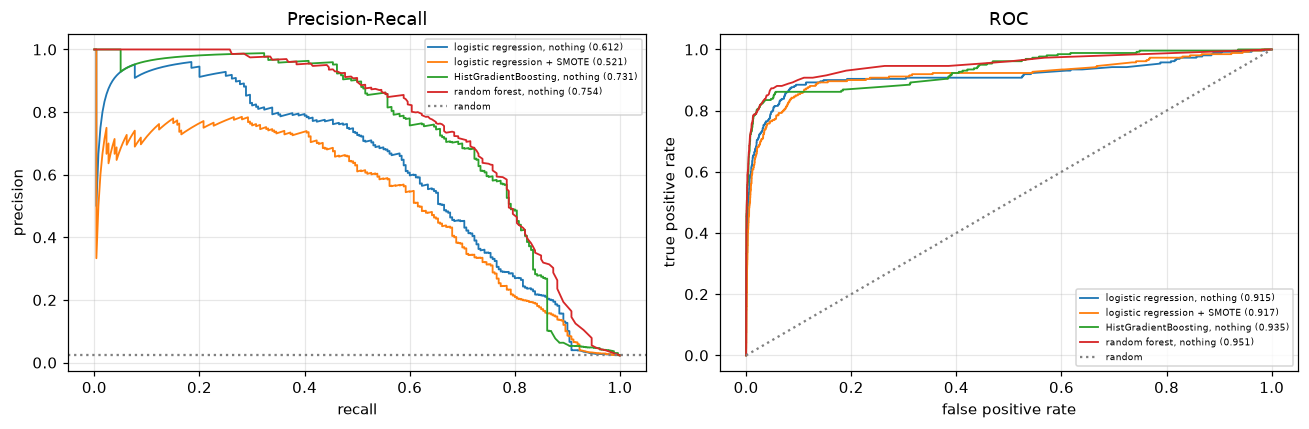

The two panels tell different stories about the same four models.

On ROC they are bunched together near the top-left and all look excellent. On PR they
separate clearly and none looks excellent.

At a 2.3% base rate the ROC panel is the misleading one, for the reason in 1.2: its
x-axis is the false-positive RATE, and 100 false alarms out of 10,900 negatives moves
it by 0.009. Those same 100 false alarms are most of what a radiologist would see.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in ["logistic regression, nothing", "logistic regression + SMOTE",
             "HistGradientBoosting, nothing", "random forest, nothing"]:
    p = probas_m[name]
    prec, rec, _ = precision_recall_curve(ym, p)
    axes[0].plot(rec, prec, lw=1.2,
                 label=f"{name} ({average_precision_score(ym, p):.3f})")
    fpr, tpr, _ = roc_curve(ym, p)
    axes[1].plot(fpr, tpr, lw=1.2, label=f"{name} ({roc_auc_score(ym, p):.3f})")
axes[0].axhline(ym.mean(), ls=":", color="gray", label="random")
axes[0].set(xlabel="recall", ylabel="precision", title="Precision-Recall")
axes[1].plot([0, 1], [0, 1], ls=":", color="gray", label="random")
axes[1].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
for ax in axes:
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("The two panels tell different stories about the same four models.")
print()
print("On ROC they are bunched together near the top-left and all look excellent. On PR they")
print("separate clearly and none looks excellent.")
print()
print("At a 2.3% base rate the ROC panel is the misleading one, for the reason in 1.2: its")
print("x-axis is the false-positive RATE, and 100 false alarms out of 10,900 negatives moves")
print("it by 0.009. Those same 100 false alarms are most of what a radiologist would see.")

***
# Part 3 - The two things that actually matter

Everything so far has been about which lever to pull. This part is about the two decisions that
change your results by more than any of them.

## 3.1 The resampling leak

**Resampling must happen inside the cross-validation fold.** Doing it to the whole dataset
before splitting is the most common mistake in this topic, and it is the largest leak measured
anywhere in this series.

Why it leaks: SMOTE synthesises points by interpolating between minority neighbours. If it runs
before the split, synthetic points built *from* a row can land in the training fold while the
row itself is in the validation fold. The model has effectively seen the answer. Random
oversampling is worse still — it puts literal duplicates on both sides.

The clean way to measure it is data with **no signal at all**: labels independent of features,
so honest cross-validation must return chance.

In [17]:
rng = np.random.default_rng(RANDOM_STATE)
n_noise, p_noise = 1000, 50
X_noise = rng.normal(size=(n_noise, p_noise))
y_noise = (rng.random(n_noise) < 0.05).astype(int)     # 5% positives, PURE NOISE

print(f"{n_noise} samples, {p_noise} features, {y_noise.sum()} positives "
      f"({y_noise.mean():.1%})")
print(f"y is independent of X, so the truth is: ROC-AUC 0.50, PR-AUC {y_noise.mean():.3f}\n")

# WRONG - resample everything, then cross-validate
X_leak, y_leak = SMOTE(random_state=RANDOM_STATE).fit_resample(X_noise, y_noise)
leaked = cross_validate(LogisticRegression(max_iter=3000), X_leak, y_leak, cv=SKF,
                        scoring={k: SCORING[k] for k in
                                 ["roc_auc", "average_precision", "recall", "f1"]})

# RIGHT - resample inside each training fold
honest = cross_validate(
    ImbPipeline([("sm", SMOTE(random_state=RANDOM_STATE)),
                 ("clf", LogisticRegression(max_iter=3000))]),
    X_noise, y_noise, cv=SKF,
    scoring={k: SCORING[k] for k in
             ["roc_auc", "average_precision", "recall", "f1"]})

print(f"{'metric':<22} {'SMOTE before CV':>17} {'SMOTE in pipeline':>19} {'inflation':>11}")
print("-" * 74)
for m in ["roc_auc", "average_precision", "recall", "f1"]:
    a, b = leaked[f"test_{m}"].mean(), honest[f"test_{m}"].mean()
    print(f"{m:<22} {a:>17.4f} {b:>19.4f} {a - b:>+11.4f}")

print()
print("Read that again. On data containing NO INFORMATION WHATSOEVER, resampling before")
print("cross-validation produces an ROC-AUC of 0.83 and a PR-AUC of 0.76.")
print()
print("Those are numbers people publish. They are numbers people deploy on.")
print()
print("The pipeline version returns approximately chance, which is the correct answer.")

1000 samples, 50 features, 43 positives (4.3%)
y is independent of X, so the truth is: ROC-AUC 0.50, PR-AUC 0.043

metric                   SMOTE before CV   SMOTE in pipeline   inflation
--------------------------------------------------------------------------
roc_auc                           0.8323              0.4948     +0.3376
average_precision                 0.7591              0.0576     +0.7015
recall                            0.8119              0.2750     +0.5369
f1                                0.7783              0.0788     +0.6994

Read that again. On data containing NO INFORMATION WHATSOEVER, resampling before
cross-validation produces an ROC-AUC of 0.83 and a PR-AUC of 0.76.

Those are numbers people publish. They are numbers people deploy on.

The pipeline version returns approximately chance, which is the correct answer.


In [18]:
# It is not only a pure-noise curiosity.
X_leak2, y_leak2 = SMOTE(random_state=RANDOM_STATE).fit_resample(X, y)
lk = cross_validate(LogisticRegression(max_iter=3000), X_leak2, y_leak2, cv=SKF,
                    scoring=["roc_auc", "average_precision"])
hn = cross_validate(ImbPipeline([("sm", SMOTE(random_state=RANDOM_STATE)),
                                 ("clf", LogisticRegression(max_iter=3000))]),
                    X, y, cv=SKF, scoring=["roc_auc", "average_precision"])

print("Same test on the Part 1 data, which does have real signal:\n")
print(f"{'metric':<22} {'before CV':>12} {'in pipeline':>13} {'inflation':>11}")
print("-" * 62)
for m in ["roc_auc", "average_precision"]:
    a, b = lk[f"test_{m}"].mean(), hn[f"test_{m}"].mean()
    print(f"{m:<22} {a:>12.4f} {b:>13.4f} {a - b:>+11.4f}")

print("\nA precision point before comparing samplers, because it affects the headline above.")
print()
print("PR-AUC's baseline is the POSITIVE RATE. Resampling makes the set 50% positive, so a")
print("random model scores 0.50 there against 0.043 here - part of that +0.70 'inflation' is")
print("a baseline shift, not leakage.")
print()
print("ROC-AUC has a baseline of 0.50 at ANY class balance, so it isolates the genuine")
print("information leakage. That is the honest column to compare samplers on:\n")
print(f"  {'sampler':<24} {'ROC before CV':>15} {'in pipeline':>13} {'leakage':>10} "
      f"{'rows':>7}")
print("  " + "-" * 74)
for name, sampler in [("RandomOverSampler", RandomOverSampler(random_state=RANDOM_STATE)),
                      ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
                      ("ADASYN", ADASYN(random_state=RANDOM_STATE)),
                      ("RandomUnderSampler", RandomUnderSampler(random_state=RANDOM_STATE))]:
    Xl, yl = sampler.fit_resample(X_noise, y_noise)
    a = cross_validate(LogisticRegression(max_iter=3000), Xl, yl, cv=SKF,
                       scoring=["roc_auc"])["test_roc_auc"].mean()
    b = cross_validate(ImbPipeline([("s", sampler),
                                    ("clf", LogisticRegression(max_iter=3000))]),
                       X_noise, y_noise, cv=SKF,
                       scoring=["roc_auc"])["test_roc_auc"].mean()
    print(f"  {name:<24} {a:>15.4f} {b:>13.4f} {a - b:>+10.4f} {len(yl):>7}")

print()
print("Every sampler fabricates 0.20 to 0.34 of ROC-AUC out of noise, and ROC-AUC cannot be")
print("explained away by a baseline shift. The leak is real.")
print()
print("The oversamplers leak most, and the mechanism is direct: a synthetic or duplicated row")
print("built FROM a validation row sits in the training fold, so the model has seen it.")
print()
print("RandomUnderSampler leaks less because it copies nothing - but note the last column.")
print("It reduced 1,000 rows to 86, and a 50-feature model on 68 training rows overfits")
print("wildly. Its inflation is as much small-sample noise as leakage, which is its own")
print("reason not to evaluate that way.")
print()
print("THE RULE: use `imblearn.pipeline.Pipeline`, not `sklearn.pipeline.Pipeline`. The")
print("imblearn version applies samplers during `fit` only, and skips them at `predict` and")
print("during scoring. sklearn's own Pipeline cannot hold a sampler at all, which is a")
print("deliberate and helpful refusal.")
print()
print("And never, ever call `fit_resample` on your full dataset and then split.")

Same test on the Part 1 data, which does have real signal:

metric                    before CV   in pipeline   inflation
--------------------------------------------------------------
roc_auc                      0.7734        0.7210     +0.0523
average_precision            0.7308        0.0770     +0.6539

A precision point before comparing samplers, because it affects the headline above.

PR-AUC's baseline is the POSITIVE RATE. Resampling makes the set 50% positive, so a
random model scores 0.50 there against 0.043 here - part of that +0.70 'inflation' is
a baseline shift, not leakage.

ROC-AUC has a baseline of 0.50 at ANY class balance, so it isolates the genuine
information leakage. That is the honest column to compare samplers on:

  sampler                    ROC before CV   in pipeline    leakage    rows
  --------------------------------------------------------------------------
  RandomOverSampler                 0.7921        0.4684    +0.3237    1914
  SMOTE               

## 3.2 Choosing the threshold from costs

§1.6 showed the threshold is the real lever. This is how to set it: not by maximising F1, which
is a metric with no connection to your problem, but from **what each kind of error actually
costs**.

If a false negative costs $C_{FN}$ and a false positive costs $C_{FP}$, the expected cost of
flagging a row with probability $p$ is minimised by flagging when

$$ p \;>\; \frac{C_{FP}}{C_{FP} + C_{FN}} $$

For a 10:1 cost ratio that is a threshold of 0.09, not 0.5.

In [19]:
p_gb = probas_m["HistGradientBoosting, nothing"]
grid = np.linspace(0.001, 0.9, 500)

print("Threshold sweep on the untreated gradient-boosting model:\n")
print(f"  {'threshold':>10} {'precision':>11} {'recall':>9} {'F1':>8} {'flagged':>9} "
      f"{'missed':>8}")
print("  " + "-" * 62)
for t in [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]:
    pred = (p_gb >= t).astype(int)
    if pred.sum() == 0:
        continue
    tn, fp, fn, tp = confusion_matrix(ym, pred).ravel()
    print(f"  {t:>10.2f} {precision_score(ym, pred, zero_division=0):>11.4f} "
          f"{recall_score(ym, pred, zero_division=0):>9.4f} {f1_score(ym, pred, zero_division=0):>8.4f} {pred.sum():>9} "
          f"{fn:>8}")

best_f1_t = max(grid, key=lambda t: f1_score(ym, (p_gb >= t).astype(int)))
print(f"\n  best-F1 threshold {best_f1_t:.4f} -> F1 "
      f"{f1_score(ym, (p_gb >= best_f1_t).astype(int)):.4f}")
print(f"  F1 at the default 0.5: {f1_score(ym, (p_gb >= 0.5).astype(int)):.4f}")
print()
print("  But F1 weights precision and recall equally, which is a claim about your problem")
print("  that is almost never true. Here it is certainly false.")

Threshold sweep on the untreated gradient-boosting model:

   threshold   precision    recall       F1   flagged   missed
  --------------------------------------------------------------
        0.50      0.7947    0.5808   0.6711       190      109
        0.30      0.7642    0.6231   0.6864       212       98
        0.20      0.7160    0.6692   0.6918       243       86
        0.10      0.6596    0.7231   0.6899       285       72
        0.05      0.5776    0.7731   0.6612       348       59
        0.02      0.4827    0.8038   0.6032       433       51

  best-F1 threshold 0.1217 -> F1 0.7028
  F1 at the default 0.5: 0.6711

  But F1 weights precision and recall equally, which is a claim about your problem
  that is almost never true. Here it is certainly false.


Now choose the threshold from the cost of each error instead.

   FN:FP cost  empirical   formula  precision   recall  missed  flagged
  --------------------------------------------------------------------
          1:1     0.6262    0.5000     0.8580   0.5577     115      169
          5:1     0.0460    0.1667     0.5682   0.7846      56      359
         10:1     0.0460    0.0909     0.5682   0.7846      56      359
         50:1     0.0028    0.0196     0.2711   0.8538      38      819
        100:1     0.0028    0.0099     0.2711   0.8538      38      819


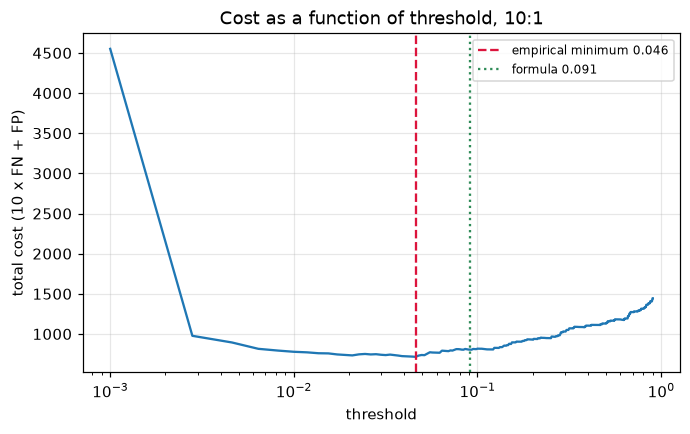


Two things to notice, and the second is the more useful.

1. The empirical minimum and the formula do NOT agree. The formula assumes the
   probabilities are calibrated; this model's are not exactly, so the cost-optimal
   cut sits lower than theory predicts. Either calibrate the model first (NB-00
   section 7) or - as here - just search the grid, which needs no assumption.

2. The cost curve is FLAT near its minimum. Two quite different thresholds can give
   almost the same expected cost, which means the exact value does not need defending
   to three decimal places. What needs defending is the COST RATIO - and that is a
   conversation with the radiologists, not an analysis you can do alone.

This is the honest end point of the whole notebook: the hardest part of imbalanced
classification is not an algorithm, it is getting someone to tell you what a miss
is worth.


In [20]:
def total_cost(threshold, c_fn, c_fp=1):
    tn, fp, fn, tp = confusion_matrix(ym, (p_gb >= threshold).astype(int)).ravel()
    return c_fn * fn + c_fp * fp


print("Now choose the threshold from the cost of each error instead.\n")
print(f"  {'FN:FP cost':>11} {'empirical':>10} {'formula':>9} {'precision':>10} "
      f"{'recall':>8} {'missed':>7} {'flagged':>8}")
print("  " + "-" * 68)
for ratio in [1, 5, 10, 50, 100]:
    emp = min(grid, key=lambda t: total_cost(t, ratio))
    theory = 1 / (1 + ratio)
    pred = (p_gb >= emp).astype(int)
    tn, fp, fn, tp = confusion_matrix(ym, pred).ravel()
    print(f"  {ratio:>9}:1 {emp:>10.4f} {theory:>9.4f} "
          f"{precision_score(ym, pred, zero_division=0):>10.4f} "
          f"{recall_score(ym, pred, zero_division=0):>8.4f} {fn:>7} {pred.sum():>8}")

costs = [total_cost(t, 10) for t in grid]
plt.plot(grid, costs)
plt.axvline(grid[int(np.argmin(costs))], color="crimson", ls="--",
            label=f"empirical minimum {grid[int(np.argmin(costs))]:.3f}")
plt.axvline(1 / 11, color="seagreen", ls=":", label=f"formula {1/11:.3f}")
plt.xlabel("threshold"); plt.ylabel("total cost (10 x FN + FP)")
plt.title("Cost as a function of threshold, 10:1")
plt.xscale("log"); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print()
print("Two things to notice, and the second is the more useful.")
print()
print("1. The empirical minimum and the formula do NOT agree. The formula assumes the")
print("   probabilities are calibrated; this model's are not exactly, so the cost-optimal")
print("   cut sits lower than theory predicts. Either calibrate the model first (NB-00")
print("   section 7) or - as here - just search the grid, which needs no assumption.")
print()
print("2. The cost curve is FLAT near its minimum. Two quite different thresholds can give")
print("   almost the same expected cost, which means the exact value does not need defending")
print("   to three decimal places. What needs defending is the COST RATIO - and that is a")
print("   conversation with the radiologists, not an analysis you can do alone.")
print()
print("This is the honest end point of the whole notebook: the hardest part of imbalanced")
print("classification is not an algorithm, it is getting someone to tell you what a miss")
print("is worth.")

In [21]:
# sklearn can do this search for you, inside cross-validation.
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import make_scorer


def negative_cost(y_true, y_pred, c_fn=10, c_fp=1):
    """Cost as a GAIN (negated), because scorers are maximised."""
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return -(c_fn * fn + c_fp * fp)


tuned = TunedThresholdClassifierCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    scoring=make_scorer(negative_cost, response_method="predict"),
    cv=5, random_state=RANDOM_STATE,
)
Xtr_m, Xte_m, ytr_m, yte_m = train_test_split(Xm, ym, test_size=0.3, stratify=ym,
                                              random_state=RANDOM_STATE)
tuned.fit(Xtr_m, ytr_m)
plain = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xtr_m, ytr_m)

print(f"TunedThresholdClassifierCV chose threshold {tuned.best_threshold_:.4f}\n")
print(f"{'model':<40} {'missed (FN)':>13} {'false alarms':>14} {'cost @10:1':>12}")
print("-" * 82)
for name, pred in [("default threshold 0.5", plain.predict(Xte_m)),
                   ("cost-tuned threshold", tuned.predict(Xte_m))]:
    tn, fp, fn, tp = confusion_matrix(yte_m, pred).ravel()
    print(f"{name:<40} {fn:>13} {fp:>14} {10 * fn + fp:>12}")

print()
print("`TunedThresholdClassifierCV` (sklearn 1.5+) does the whole job: it fits the model,")
print("searches thresholds by cross-validation against YOUR scoring function, and returns an")
print("estimator whose predict() already uses the chosen cut. It is the tool this section")
print("argues for, and it makes threshold tuning as easy as passing class_weight - with none")
print("of the calibration damage from 1.8.")

TunedThresholdClassifierCV chose threshold 0.0505

model                                      missed (FN)   false alarms   cost @10:1
----------------------------------------------------------------------------------
default threshold 0.5                               33             12          342
cost-tuned threshold                                16             35          195

`TunedThresholdClassifierCV` (sklearn 1.5+) does the whole job: it fits the model,
searches thresholds by cross-validation against YOUR scoring function, and returns an
estimator whose predict() already uses the chosen cut. It is the tool this section
argues for, and it makes threshold tuning as easy as passing class_weight - with none
of the calibration damage from 1.8.


***
# Part 4 - Tough questions

***

### Q1. Your model is 99% accurate on a fraud dataset. Your manager is delighted. What do you say?

<details><summary>Answer</summary>

**"What does a model that predicts 'not fraud' every single time score?"**

If fraud is 1% of transactions, that model also scores 99%. §1.1 measures exactly this:
accuracy **0.9840** with recall **0.0000** — the model has never once identified the thing it
was built to find.

**What to report instead**, in roughly this order:

1. **The baseline.** Every accuracy number on imbalanced data is meaningless without the
   majority-class rate beside it.
2. **Counts of the thing you care about.** "We catch 58 of the 100 frauds and raise 190 false
   alarms" is a sentence a business owner can respond to. §2.2 reports the mammography model
   that way deliberately.
3. **PR-AUC, compared against the positive rate.** A random model scores exactly the positive
   rate, so quote the lift: §2.2's model scores 0.61 against a floor of 0.023 — a **26×** lift.

**Do not lead with ROC-AUC.** It is not fooled by class balance the way accuracy is (it
correctly gives the do-nothing model 0.50), but §1.2 shows it staying essentially flat —
0.8695 to 0.8437 — while PR-AUC collapses from 0.8775 to 0.2152 on the *same signal*. It is
answering a question about ranking, not about what happens when you act on the predictions.

</details>

***

### Q2. When is ROC-AUC misleading, and what replaces it?

<details><summary>Answer</summary>

**Whenever the negative class is much larger and false positives cost you something.**

The mechanism is in the denominators:

- ROC plots recall against the **false-positive rate**, $FP/(FP+TN)$. $TN$ is enormous, so a
  flood of false positives moves the curve barely at all.
- PR plots precision, $TP/(TP+FP)$, whose denominator is **what you flagged**. Every false
  positive is felt immediately.

§1.2 holds the signal constant and varies only the class balance:

| minority | ROC-AUC | PR-AUC |
|---|---|---|
| 50% | 0.8695 | 0.8775 |
| 1% | **0.8437** | **0.2152** |

Both are telling the truth. ROC says the *ranking* is just as good, and it is. PR says that if
you act on the flagged rows most will be wrong, and they will be.

**Use PR-AUC (average precision)** as the headline for imbalanced problems — and always beside
the positive rate, since that is what a random model scores. §2.3 shows the same four models
looking bunched and excellent on ROC and clearly separated and unimpressive on PR.

**ROC-AUC still has uses:** comparing models across datasets with different base rates, and
when false positives are genuinely cheap. It is also insensitive to class balance, which is
occasionally what you want.

</details>

***

### Q3. Walk through SMOTE. What does it actually do?

<details><summary>Answer</summary>

For each synthetic point: pick a minority point $x$, pick one of its $k$ nearest **minority**
neighbours $x'$, and place a new minority point at $x + \lambda(x' - x)$ with
$\lambda \sim U(0,1)$. Repeat until balanced. §1.4 implements it in four lines and matches
`imblearn` exactly.

**Two properties follow directly from that construction**, and they explain everything else:

1. **Every synthetic point lies inside the convex hull of the minority points you already
   have.** SMOTE cannot invent minority structure in a region where you have no minority
   examples — it fills in between the ones you do. It adds no information.
2. **It runs on nearest neighbours**, so it inherits every property of NB-07: it needs scaled
   features, and it degrades when distances stop being meaningful.

**Versus random oversampling:** duplicates sit exactly on top of the originals (§1.4's middle
panel looks unchanged), so a model can memorise them. SMOTE spreads the class out, which is a
mild regulariser — and also how it goes wrong (Q4).

**The variants** all address the same weakness: `BorderlineSMOTE` synthesises only near the
decision boundary, `ADASYN` weights toward hard regions, `SMOTETomek` cleans up afterwards by
removing pairs that straddle the boundary. §1.5 measures them; none rescued the baseline here.

</details>

***

### Q4. When does SMOTE make things worse?

<details><summary>Answer</summary>

Three situations, and §1.5 measures all three.

**1. Overlapping classes.** SMOTE draws a straight line between two minority points and puts a
new minority point on it. If the classes overlap, that line passes through majority territory,
and you have manufactured mislabelled training data:

| class separation | baseline PR-AUC | SMOTE PR-AUC |
|---|---|---|
| 2.0 | 0.7418 | 0.7287 |
| 1.0 | 0.4460 | 0.3736 |
| 0.5 | 0.2469 | 0.1739 |

The damage grows as the classes overlap — exactly as the mechanism predicts.

**2. Categorical features** — but *conditionally*, and the condition is worth knowing.
Interpolating between category 1 and category 3 gives "category 2.4", which does not exist.
But §1.5 measures that this **does not happen** with one categorical column and a few numeric
ones: the category dominates the distance, so a point's nearest minority neighbours share its
category (**100%** of the time), and interpolation returns that category unchanged.

It breaks when the categorical column is a *small share of the distance*:

| setup | invalid synthetic categories |
|---|---|
| 1 categorical + 3 numeric | **0%** |
| 1 categorical + 30 numeric | 29.6% |
| 20 levels + 30 numeric | 85.7% |
| 50 levels + 30 numeric | **92.8%** |

So the rule is not "never use SMOTE with categoricals" — it is "SMOTE corrupts a categorical
column when that column is a small part of the distance", which many numeric features or many
levels both cause. Use **`SMOTENC`**, which resamples categorical columns by majority vote
among the neighbours instead of averaging.

**3. Very few minority points.** With 10 positives, SMOTE interpolates among 10 points and
mostly produces near-duplicates. There is no structure to interpolate.

</details>

***

### Q5. Does resampling actually improve model performance?

<details><summary>Answer</summary>

**Almost never, on the metric that matters.** §1.7 sweeps dimensionality, imbalance ratio and
class separation — **12 configurations**. SMOTE reduced PR-AUC in **11** of them, mean change
**−0.0525**, worst **−0.0962**. The single improvement was **+0.0029** at 1,000 features, where
both models were near the floor anyway.

§2.3 reproduces the pattern on real mammography data: untreated logistic regression has the
best PR-AUC of the four logistic variants.

**Why that is not surprising:** resampling adds no observations. It reweights or interpolates
what you already have. It cannot create signal, so it cannot improve the *ranking* of rows by
risk — which is what PR-AUC and ROC-AUC measure.

**What it does do**, reliably: raise recall at a fixed threshold. §1.3 shows recall going from
0.00 to 0.6–0.7 under every treatment. That is real, that is what people see, and it is why
resampling feels like it works.

**But §1.6 gets the same thing for free.** Tuning the threshold on the untouched model gave
**F1 0.1341** against SMOTE's **0.0581** — more than double — with no second fit, no discarded
data, and no calibration damage (§1.8).

**Be careful not to overstate this.** The claim is that resampling does not add information and
is usually dominated by threshold tuning. It is *not* that it never helps: §2.3 shows SMOTE
edging ahead for the gradient-boosted model on real data. Measure on your data.

**Where resampling still earns its place:** when the learner accepts neither class weights nor
a custom threshold; when undersampling makes an intractably large dataset trainable; or when a
downstream system demands a balanced training set.

</details>

***

### Q6. What is the most common mistake in imbalanced classification?

<details><summary>Answer</summary>

**Resampling before splitting, instead of inside the cross-validation fold.**

§3.1 measures it on data with **no signal at all** — labels independent of features, so honest
CV must return chance:

| metric | SMOTE before CV | SMOTE in pipeline | truth |
|---|---|---|---|
| ROC-AUC | **0.8323** | 0.4948 | 0.50 |
| PR-AUC | 0.7591 | 0.0576 | 0.043 |
| F1 | 0.7783 | 0.0788 | ~0 |

**An ROC-AUC of 0.83 from pure noise.** This is the largest leak measured anywhere in this
series, and it produces numbers people publish and deploy on.

**Read the ROC row, not the PR row, when judging the size of the leak.** PR-AUC's baseline is
the positive rate, and the resampled set is 50% positive rather than 4.3% — so part of that
PR gap is a baseline shift rather than leakage. ROC-AUC has a baseline of 0.50 at any class
balance, which is why §3.1 uses it to compare samplers. The leak is unambiguous either way;
being precise about which part is which is the difference between a claim that survives
scrutiny and one that does not.

**Why it leaks:** SMOTE builds synthetic points by interpolating between minority neighbours.
Run before the split, a synthetic point built *from* a validation row lands in the training
fold — the model has seen the answer. Random oversampling is worse: it puts literal duplicates
on both sides. §3.1 shows `RandomUnderSampler` leaking least, because it duplicates nothing.

**The fix is one import.** Use `imblearn.pipeline.Pipeline`, which applies samplers during
`fit` only and skips them at `predict` and during scoring. sklearn's own `Pipeline` refuses to
hold a sampler at all, which is a deliberate and helpful refusal.

Never call `fit_resample` on your full dataset and then split.

</details>

***

### Q7. You resampled, and now your probabilities are wrong. Why, and how do you fix it?

<details><summary>Answer</summary>

**A model learns $P(y \mid x)$ for the distribution it was trained on.** Resampling changes the
class balance, so the model is calibrated to a world where positives are far commoner than they
are.

§1.8 measures it on data with a true positive rate of 0.0160:

| model | Brier | mean predicted P |
|---|---|---|
| no resampling | **0.0157** | **0.0168** |
| class_weight='balanced' | 0.1990 | 0.3947 |
| SMOTE | 0.1930 | 0.3700 |
| random undersampling | 0.2272 | 0.4101 |

A calibrated model's mean prediction should match the true rate. The untouched model does that
almost exactly; every treatment lands an order of magnitude too high, and Brier degrades by
more than 10×.

**When it matters:** any time the *number* is used rather than the ranking — expected-value
calculations, risk scores shown to a human, a downstream model, or a threshold chosen from
costs (§3.2, where the theoretical formula assumes calibration and visibly disagrees with the
empirical optimum because of it).

**Three fixes, in order of preference:**

1. **Do not resample.** §1.6 gets the same operating point from the threshold with calibration
   intact.
2. **Recalibrate afterwards** on data with the *original* class balance —
   `CalibratedClassifierCV` (NB-00 §7, NB-02 Part 3).
3. **Correct the prior analytically.** If you undersampled the majority by a factor $r$, the
   corrected odds are the model's odds divided by $r$. Exact for undersampling, approximate
   for SMOTE.

</details>

***

### Q8. Class weights or resampling — what is the difference?

<details><summary>Answer</summary>

**Less than you would think.** Weighting a class by $w$ and duplicating its rows $w$ times give
the same expected gradient for most losses. §1.3 measures them landing in the same place:
recall 0.6000 for `class_weight='balanced'` and 0.6000 for random oversampling.

| | class weights | resampling |
|---|---|---|
| Changes the data | no | **yes** |
| Memory / time | unchanged | oversampling grows the set; undersampling shrinks it |
| Discards information | no | **undersampling does** |
| Works with any learner | only if it accepts `sample_weight` | **yes** |
| Can synthesise new points | no | SMOTE does |
| Damages calibration | **yes** (§1.8) | **yes** (§1.8) |

**Prefer class weights** when the learner supports them: no data is copied or thrown away, it
is one parameter, and it is trivially reversible.

**Prefer resampling** when the learner does not accept weights, or when undersampling is what
makes a huge dataset trainable at all.

**Prefer neither, usually.** Both distort your probabilities to move an operating point that
the threshold moves for free (§1.6). The one thing class weights have over both is that
`class_weight='balanced'` is a single argument — which is precisely why it gets used without
anyone checking whether it helped.

</details>

***

### Q9. How do you choose the decision threshold?

<details><summary>Answer</summary>

**From the cost of each error — not from F1, and certainly not by leaving it at 0.5.**

If a false negative costs $C_{FN}$ and a false positive costs $C_{FP}$, the expected cost is
minimised by flagging when

$$ p > \frac{C_{FP}}{C_{FP} + C_{FN}} $$

At a 10:1 ratio that is **0.09**, not 0.5. §3.2 works this through on mammography.

**Three practical warnings from the measurements:**

1. **The formula assumes calibrated probabilities.** §3.2 finds the empirical cost-optimal
   threshold sitting well below the formula's value, because the model is only approximately
   calibrated. Either calibrate first, or search the grid — the grid needs no assumption.
2. **The cost curve is flat near its minimum.** Two quite different thresholds give nearly the
   same expected cost, so the exact value does not need defending to three decimals. What needs
   defending is the **cost ratio**.
3. **Tune it on validation data, never on test** — the threshold is a fitted parameter like any
   other. `TunedThresholdClassifierCV` (sklearn 1.5+) does the whole thing inside
   cross-validation against a scoring function you supply.

**Why not maximise F1?** F1 weights precision and recall equally, which is a strong claim about
your problem that is almost never true. For mammography it is plainly false: a missed
microcalcification and a follow-up scan are not comparable.

**The honest end point:** the hard part is not the arithmetic. It is getting a domain expert to
tell you what a miss is worth. That conversation is the actual deliverable.

</details>

***

### Q10. Fraud detection: 0.1% positives, 10 million transactions. How do you approach it?

<details><summary>Answer</summary>

1. **Establish what an error costs** before modelling. A missed fraud costs the transaction
   value; a false positive costs a review, plus customer annoyance that is real but harder to
   price. This determines the threshold (Q9) and it is the only part nobody else can do for you.
2. **Split by time, not randomly.** Fraud patterns evolve, and a random split lets you train on
   next month's tactics. This is NB-00 §2's time leakage, and it matters more here than the
   imbalance does.
3. **Check for group leakage.** Multiple transactions per card, per merchant, per device. Use
   `GroupKFold` on the entity, or you are memorising cards rather than learning fraud.
4. **Feature engineering beats every technique in this notebook.** Velocity features, deviation
   from the customer's own baseline, merchant risk, time since last transaction. §2.3's honest
   finding — that model choice moved PR-AUC from 0.61 to 0.75 while resampling moved it by
   hundredths — applies twice as strongly to features.
5. **Undersample the majority for tractability**, if 10M rows is the binding constraint. This
   is the case where resampling genuinely earns its place (Q5) — and remember to correct the
   prior afterwards (Q7).
6. **Use a gradient-boosted tree.** It handles mixed types, needs no scaling, and §2.3 shows
   the model choice mattering more than the imbalance treatment.
7. **Measure with PR-AUC**, and report precision at the review capacity you actually have —
   "of the 500 transactions we can review per day, how many are fraud?" is the real metric.
8. **Set the threshold from step 1** (§3.2), and monitor it. Fraud rates drift, so a fixed
   threshold silently changes its meaning.

**What not to do:** reach for SMOTE first. §1.7 and §2.3 both suggest it will not help, and on
10M rows it is expensive.

</details>

***

### Q11. Your recall is 0.95 and precision is 0.02. Is the model useful?

<details><summary>Answer</summary>

**It depends entirely on the cost ratio and your review capacity — but be precise about what
those numbers mean.**

Precision 0.02 means **49 of every 50 flagged rows are wrong**. At 1% positives a random model
gets 0.01, so 0.02 is a 2× lift — genuinely poor.

**Where it can still be useful:**

- **Screening**, where a cheap flag routes to an expensive-but-accurate second stage. Catching
  95% and passing 50× the volume to review is a legitimate design if review is affordable.
- **Extreme cost asymmetry.** At 1000:1, 49 wasted reviews to catch one case is a good trade.

**Where it is not:**

- **If a human sees every alert.** They will stop reading them. Alert fatigue is a real failure
  mode, and a model that is ignored has zero recall in practice.
- **If it acts automatically** — blocking cards, rejecting applications — 49 false accusations
  per catch is not deployable.

**What to do about it:**

1. **Move the threshold up.** §3.2's sweep shows precision and recall trading directly. You
   likely chose 0.95 recall by accident, via a default or a `class_weight` setting.
2. **Compute the actual cost** at several thresholds and pick the minimum (§3.2).
3. **Report precision at your capacity.** If you can review 100 rows a day, "precision in the
   top 100 by score" is the number that matters, and it will be far better than 0.02.
4. **Check PR-AUC.** If it is near the positive rate, no threshold will save you — the model
   has no signal and the problem is your features, not your cut-off.

</details>

***

### Q12. Your model performed well in validation and poorly in production. What imbalance-specific things do you check?

<details><summary>Answer</summary>

Beyond the general causes (NB-00 Part 9), five specific to this topic:

1. **Resampling outside the CV fold.** Check this first — §3.1 shows it manufacturing ROC-AUC
   0.83 from pure noise. Look for any `fit_resample` call that is not inside an
   `imblearn.pipeline.Pipeline`. This single mistake explains more "great in validation, awful
   in production" stories than everything else combined.
2. **The base rate changed.** Your threshold encodes an assumed positive rate. If fraud drops
   from 1% to 0.3%, a fixed threshold now flags three times as many false positives per catch.
   Monitor the positive rate and the flag rate; recompute the threshold when either moves.
3. **The threshold was tuned on the test set.** It is a fitted parameter. Tuning it on the data
   you report is the same mistake as tuning any hyperparameter there.
4. **Probabilities were used but the model was resampled** (§1.8, Q7). If anything downstream
   consumes the number — an expected-value rule, a risk band — resampling shifted it by an
   order of magnitude.
5. **Group or time leakage inflated validation.** With few positives, a handful of duplicated
   entities across the split moves the metrics a lot. At 100 positives, 5 leaked rows is 5% of
   your signal.

**What to monitor:** the positive rate, the flag rate, precision on whatever subset gets
reviewed (that is free labelled data), and the score distribution. A drifting score
distribution with a fixed threshold is a silently changing model.

</details>

***

## Coding challenges

### Challenge 1 — build the leak, then measure it across samplers

§3.1 measured SMOTE. Do the whole family properly.

1. Generate pure-noise data as §3.1 does: `X` random, `y` random at 5% positive, no
   relationship.
2. For each of `RandomOverSampler`, `SMOTE`, `BorderlineSMOTE`, `ADASYN`, `SMOTETomek`,
   `RandomUnderSampler`, `TomekLinks`: compute PR-AUC both ways — resampled before CV, and
   inside an `ImbPipeline`.
3. Plot the inflation per sampler. Rank them. Explain the ordering in terms of *how many
   duplicated or interpolated rows can straddle the split*.
4. Vary the minority rate from 20% down to 1%. Does the leak grow as the minority shrinks?
   Predict the answer before running it — with fewer minority points, each one is used in more
   synthetic points.
5. Repeat with `GroupKFold` where groups are deliberately correlated. How do the two leaks
   compound?

***

### Challenge 2 — the cost-curve deliverable

Turn §3.2 into something you could actually take to a stakeholder.

1. On mammography, fit a gradient-boosted model with proper cross-validation and get
   out-of-fold probabilities.
2. Build a function `expected_cost(threshold, c_fn, c_fp)` and plot cost against threshold for
   several cost ratios on one chart.
3. Add a second axis showing *how many cases get flagged* at each threshold — the capacity
   constraint is usually the binding one in practice.
4. **Calibrate the model first** (`CalibratedClassifierCV`) and re-plot. Does the empirical
   optimum now match the $C_{FP}/(C_{FP}+C_{FN})$ formula, as §3.2 predicts it should?
5. Produce a one-page summary: "at a 10:1 cost ratio we recommend threshold X, flagging N cases
   per 1,000 scans, catching P% of microcalcifications". That page, not the model, is the
   deliverable.

***

### Challenge 3 — does any of it help on YOUR data?

Reproduce §1.7's sweep as a reusable audit.

1. Write `audit_imbalance(X, y)` that compares, all inside proper pipelines: baseline,
   `class_weight='balanced'`, random over/under-sampling, SMOTE, and **baseline + tuned
   threshold**. Report PR-AUC, ROC-AUC, best-F1 and Brier for each.
2. Run it on at least four of the Part 5 datasets.
3. Tabulate how often each approach wins on PR-AUC, and how often the tuned-threshold baseline
   wins on F1.
4. Now add a gradient-boosted tree and repeat. Does the ranking of *treatments* change with the
   model, as §2.3 hints it does?
5. Write down the conditions under which resampling helped, if any. If it never did, say that —
   a clean negative result is a finding, and it is the finding this notebook reached.

***
# Part 5 - Five datasets to practise on

`imbalanced-learn` ships a fetcher for 27 standard benchmarks, which makes this the easiest
Part 5 in the series to work through.

| # | Dataset | Shape | Minority | The skill it forces | Difficulty |
|---|---|---|---|---|---|
| 1 | **abalone** | 4,177 × 10 | 9.4% | The whole workflow at mild imbalance | ★☆☆☆☆ |
| 2 | **wine_quality** | 4,898 × 11 | 3.7% | Where treatments start to look tempting | ★★☆☆☆ |
| 3 | **mammography** | 11,183 × 6 | 2.3% | Cost-based thresholds (Part 2 and 3) | ★★★☆☆ |
| 4 | **us_crime** | 1,994 × 100 | 7.5% | **p is large, positives are few** — SMOTE's worst case | ★★★★☆ |
| 5 | **protein_homo** | 145,751 × 74 | 0.9% | Scale *and* extreme imbalance together | ★★★★★ |

In [22]:
print("These all download on first use (~1 MB each) and cache afterwards.\n")
print(f"{'dataset':<16} {'rows':>8} {'cols':>6} {'positives':>11} {'minority':>10} "
      f"{'ratio':>8}")
print("-" * 64)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_ds = fetch_datasets()
for name in ["abalone", "wine_quality", "mammography", "us_crime", "protein_homo"]:
    d = all_ds[name]
    yy = (np.asarray(d.target) == 1).astype(int)
    print(f"{name:<16} {d.data.shape[0]:>8,} {d.data.shape[1]:>6} {int(yy.sum()):>11} "
          f"{yy.mean():>9.2%} {(1-yy.mean())/yy.mean():>7.0f}:1")

print("\nA baseline on each - untreated logistic regression, PR-AUC vs the positive rate:\n")
print(f"{'dataset':<16} {'PR-AUC':>9} {'floor':>9} {'lift':>8} {'ROC-AUC':>9}")
print("-" * 56)
for name in ["abalone", "wine_quality", "mammography", "us_crime"]:
    d = all_ds[name]
    Xd, yd = np.asarray(d.data), (np.asarray(d.target) == 1).astype(int)
    p = cross_val_predict(Pipeline([("sc", StandardScaler()),
                                    ("clf", LogisticRegression(max_iter=3000))]),
                          Xd, yd, cv=SKF, method="predict_proba")[:, 1]
    ap = average_precision_score(yd, p)
    print(f"{name:<16} {ap:>9.4f} {yd.mean():>9.4f} {ap/yd.mean():>7.1f}x "
          f"{roc_auc_score(yd, p):>9.4f}")

print()
print("`protein_homo` is left out of that loop only because it is large enough to be slow.")
print()
print("Note how differently the same PR-AUC reads at different base rates. Always quote the")
print("floor beside it.")

These all download on first use (~1 MB each) and cache afterwards.

dataset              rows   cols   positives   minority    ratio
----------------------------------------------------------------
abalone             4,177     10         391     9.36%      10:1
wine_quality        4,898     11         183     3.74%      26:1
mammography        11,183      6         260     2.32%      42:1
us_crime            1,994    100         150     7.52%      12:1
protein_homo      145,751     74        1296     0.89%     111:1

A baseline on each - untreated logistic regression, PR-AUC vs the positive rate:

dataset             PR-AUC     floor     lift   ROC-AUC
--------------------------------------------------------
abalone             0.2887    0.0936     3.1x    0.8440
wine_quality        0.2165    0.0374     5.8x    0.7761
mammography         0.6125    0.0232    26.3x    0.9151
us_crime            0.5572    0.0752     7.4x    0.9116

`protein_homo` is left out of that loop only because it 

### 1. abalone — the workflow at mild imbalance

```python
from imblearn.datasets import fetch_datasets
d = fetch_datasets()["abalone"]
X, y = d.data, (d.target == 1).astype(int)
```

9.4% positives — imbalanced enough to matter, mild enough that everything still works.

1. Run the full comparison from §1.3. At this imbalance, does anything beat the baseline on
   PR-AUC?
2. Tune the threshold on the baseline (§1.6). How much of the resampling benefit does it
   recover?
3. Reproduce §3.1's leak on this dataset. Is the inflation smaller at 9.4% than at 5%? Explain
   using the mechanism, not the number.
4. Plot the PR and ROC curves side by side (§2.3). At 9.4%, do they still tell different
   stories, or does that only emerge at more extreme imbalance?

***

### 2. wine_quality — where treatments start to look tempting

```python
d = fetch_datasets()["wine_quality"]
```

3.7% positives: predicting which wines are rated excellent from physicochemical measurements.

1. Compare the three levers. Recall will jump under every treatment — check whether PR-AUC
   follows.
2. Calibration: reproduce §1.8's table. Does resampling shift the mean predicted probability
   by the same order of magnitude here?
3. Try `BorderlineSMOTE` and `ADASYN`. The classes overlap heavily in wine chemistry, which is
   §1.5's first failure mode — do the boundary-aware variants do better than plain SMOTE?
4. Now change the problem: instead of a binary "excellent" flag, predict the quality score as a
   regression. Does the imbalance problem disappear, and what replaces it?

***

### 3. mammography — cost-based decisions

Used throughout Parts 2 and 3. Go further:

1. Complete Challenge 2's cost-curve deliverable.
2. Calibrate the gradient-boosted model and check whether the cost-optimal threshold moves
   toward the theoretical formula (§3.2 predicts it should).
3. Only six features. Try engineering interactions or polynomial terms — does better feature
   work beat every imbalance technique, as §2.3's model-choice result suggests?
4. Split by a synthetic "scanner id" group and use `GroupKFold`. How much do the metrics move?
   This is what a realistic multi-site validation would show.

***

### 4. us_crime — the case SMOTE handles worst

```python
d = fetch_datasets()["us_crime"]      # 1,994 x 100, 7.5% positive
```

**100 features and 150 positives.** Q4's third failure mode: too few minority points to
interpolate meaningfully, in a space too large for distances to mean much (NB-07 §1.5).

1. Predict before running: will SMOTE help, hurt, or do nothing? Then measure it.
2. Apply PCA (NB-09) to 10 components first, then SMOTE. Does reducing the dimensionality make
   interpolation more sensible?
3. Compare against `class_weight` and threshold tuning on the untouched features.
4. With 150 positives across 5 folds, each validation fold has ~30. Compute the standard
   deviation of PR-AUC across folds — is any difference between methods larger than the noise?
   This is the question most published comparisons skip.

***

### 5. protein_homo — scale and extreme imbalance together

```python
d = fetch_datasets()["protein_homo"]   # 145,751 x 74, 0.89% positive
```

Nearly 150k rows at 112:1 imbalance.

1. Time a plain gradient-boosted fit. Now time SMOTE on 145k rows — this is where oversampling
   becomes an engineering problem, not just a statistical one.
2. Use `RandomUnderSampler` to make the problem small, fit, then **correct the prior** (Q7).
   Compare calibration before and after the correction.
3. At 0.89% positives, plot PR and ROC. This is the regime where the gap in §1.2 is widest.
4. Compute precision at k for k = 100, 500, 1000 — "if we can only investigate k cases, how
   many are real?" That is the metric this problem actually has.
5. Compare `MiniBatchKMeans`-based undersampling (cluster the majority, keep centroids) against
   random undersampling. Does the smarter method justify its cost?

***
# Part 6 - Reading the literature

An unusual literature: the foundational paper is one of the most-cited in applied ML, and much
of the best recent work argues that it does not do what people think.

## Start here

**1. [SMOTE: Synthetic Minority Over-sampling Technique](https://www.jair.org/index.php/jair/article/view/10302)** —
Nitesh Chawla, Kevin Bowyer, Lawrence Hall & W. Philip Kegelmeyer, *JAIR* 16:321–357, 2002.
**Free.**
> **Over 30,000 citations, and the source of everything in §1.4.** The idea is four lines long
> and the paper is clear about what it is doing. Read it partly for the method and partly as a
> case study in how a simple, well-communicated technique becomes a default — including in
> places its authors never claimed it would help.

**2. [The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432)** —
Takaya Saito & Marc Rehmsmeier, *PLOS ONE* 10(3), 2015. **Free.**
> **The paper behind §1.2**, and the one to send anyone reporting ROC-AUC on a 1% positive
> rate. It works through exactly why the false-positive rate hides false positives when the
> negative class is huge, with the same experiment §1.2 runs.

**3. [To SMOTE, or not to SMOTE?](https://arxiv.org/abs/2201.08528)** —
Yotam Elor & Hadar Averbuch-Elor, 2022. **Free.**
> **The paper that matches this notebook's findings.** A large empirical study across 73
> datasets and several classifiers, concluding that for strong classifiers balancing rarely
> helps, and that tuning the decision threshold recovers whatever benefit there was. §1.7 and
> §2.3 are a small replication of its result. Read it before defending SMOTE in a review.

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.1–1.2 — metrics under imbalance | **Saito & Rehmsmeier**, PLOS ONE **2015** — [link](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432) | ✅ |
| 1.2 — why average precision, and its pitfalls | **Davis & Goadrich**, *The Relationship Between Precision-Recall and ROC Curves*, ICML **2006** — [pdf](https://www.biostat.wisc.edu/~page/rocpr.pdf) | ✅ |
| 1.3 — class weights and cost-sensitive learning | **Elkan**, *The Foundations of Cost-Sensitive Learning*, IJCAI **2001** — [pdf](https://cseweb.ucsd.edu/~elkan/rescale.pdf) | ✅ |
| 1.4 — **SMOTE** | **Chawla et al.**, JAIR **2002** | ✅ |
| 1.5 — Borderline-SMOTE | **Han, Wang & Mao**, ICIC **2005** | 🔍 |
| 1.5 — ADASYN | **He, Bai, Garcia & Li**, IJCNN **2008** — [pdf](https://sci2s.ugr.es/keel/pdf/algorithm/congreso/2008-He-ieee.pdf) | ✅ |
| 1.5 — SMOTE in high dimensions | **Blagus & Lusa**, *SMOTE for high-dimensional class-imbalanced data*, BMC Bioinformatics 14, **2013** — [link](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-14-106) | ✅ |
| 1.6, 3.2 — **threshold selection** | **Elkan**, IJCAI **2001** (the $C_{FP}/(C_{FP}+C_{FN})$ result) | ✅ |
| 1.7, 2.3 — **does balancing help?** | **Elor & Averbuch-Elor**, **2022** — [arXiv](https://arxiv.org/abs/2201.08528) | ✅ |
| 1.7 — the same conclusion for clinical models | **van den Goorbergh et al.**, *The harm of class imbalance corrections for risk prediction models*, JAMIA 29(9), **2022** — [link](https://academic.oup.com/jamia/article/29/9/1525/6605096) | ✅ |
| 1.8 — **calibration damage** | **van den Goorbergh et al.**, JAMIA **2022**; and **Niculescu-Mizil & Caruana**, ICML **2005** — [pdf](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) | ✅ |
| 1.8 — correcting the prior after undersampling | **Elkan**, IJCAI **2001**; **Dal Pozzolo et al.**, *Calibrating Probability with Undersampling*, IEEE SSCI **2015** | 🔍 |
| 3.1 — resampling inside the CV fold | **Santos et al.**, *Cross-Validation for Imbalanced Datasets*, IEEE Comp. Intelligence Magazine 13(4), **2018** | 🔍 |
| Q10 — a real fraud pipeline | **Dal Pozzolo et al.**, *Credit card fraud detection: a realistic modeling and a novel learning strategy*, IEEE TNNLS **2018** | 🔍 |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### If you read only one

**Elor & Averbuch-Elor (2022), "To SMOTE, or not to SMOTE?"** — because it is the paper most
likely to change what you do on Monday, and because reading a careful large-scale negative
result is a skill worth practising. The field's default advice on this topic has been out of
date for years, and this is the clearest demonstration of that.

Then **Saito & Rehmsmeier (2015)** for the metric discipline, and **Elkan (2001)** for the
threshold formula in §3.2 — a short, clear paper that quietly contains the answer to most
imbalanced-classification questions.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| Great CV score, terrible production | **Resampling outside the CV fold** (§3.1) | `imblearn.pipeline.Pipeline` — never `fit_resample` then split |
| 99% accuracy, 0 recall | Accuracy is dominated by the majority (§1.1) | Report PR-AUC, and counts of the positive class |
| ROC-AUC 0.95 but the alerts are useless | ROC hides false positives at low base rates (§1.2) | Use PR-AUC, quoted against the positive rate |
| Probabilities all far too high | Resampling recalibrated the model to a fake prior (§1.8) | Do not resample; or recalibrate; or correct the prior |
| SMOTE made PR-AUC worse | Interpolating across overlapping classes (§1.5) | BorderlineSMOTE, or drop resampling and tune the threshold |
| Synthetic rows have impossible category values | SMOTE averaged two category codes (§1.5, Q4) | `SMOTENC`, which votes rather than averages |
| SMOTE produces near-duplicates | Too few minority points to interpolate between (Q4) | Collect more positives; use class weights instead |
| `ValueError: Expected n_neighbors <= n_samples` | Fewer minority rows than `k_neighbors + 1` | Lower `k_neighbors`, or use `RandomOverSampler` |
| Metrics swing wildly between folds | Very few positives per fold | More folds, repeated CV, and always report the std |
| `sklearn.pipeline.Pipeline` rejects the sampler | It refuses to hold one — deliberately (§3.1) | Import `Pipeline` from `imblearn.pipeline` |
| Threshold works, then degrades | The base rate drifted (Q12) | Monitor the positive and flag rates; recompute |
| `astype(str)` on a bytes column gives no `b''` | pandas 3 decodes rather than repr-ing | Compare against the decoded string, or use bytes literals |

## Checklist for shipping an imbalanced classifier

Everything in the Foundations checklist, plus:

- [ ] Is every sampler inside an **`imblearn` pipeline**, so it never touches validation data?
- [ ] Am I reporting **PR-AUC beside the positive rate**, not accuracy and not ROC-AUC alone?
- [ ] Did I compare against the **untreated baseline with a tuned threshold** before adopting
      any resampling (§1.6)?
- [ ] Is the **threshold chosen from costs**, on validation data, and written down (§3.2)?
- [ ] Do I know the **cost ratio**, and who agreed it?
- [ ] If probabilities are consumed downstream, are they **calibrated** — and did I check after
      any resampling (§1.8)?
- [ ] Is the split correct for the problem — **by time** and **by group**, not random (Q10)?
- [ ] Have I reported **counts** (missed cases, false alarms) alongside the scores?
- [ ] Is the difference between my methods larger than the **fold-to-fold standard deviation**?
- [ ] Am I monitoring the **positive rate and flag rate** in production (Q12)?

## Where to go next

| Notebook | Why it follows |
|---|---|
| [`logistic_regression_zero_to_hero.ipynb`](logistic_regression_zero_to_hero.ipynb) | Part 3 there is threshold selection and calibration in full — the two techniques this notebook leans on hardest. |
| [`gradient_boosting_zero_to_hero.ipynb`](gradient_boosting_zero_to_hero.ipynb) | §2.3 found the model choice mattering more than the imbalance treatment. This is the model. |
| `anomaly_detection_zero_to_hero.ipynb` | The limiting case: so few positives that supervised learning stops being possible at all. |
| [`kmeans_zero_to_hero.ipynb`](kmeans_zero_to_hero.ipynb) | §1.5 there shows k-means unable to find a 5-point cluster — the unsupervised version of "the objective does not care about the rare thing". |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.